# Week 1 — The Weight Matrix as an Embedding

**Pattern Interpretability in Neural Networks: the "Ideal State" project**
Nathan Haile · Fall 2026

## Mentor directive

> *Before we were considering each input and output of a layer as an embedding. Now how about
> considering the **weight matrix as an embedding**? … we can now visualize the movements of the
> model in each training epoch and study the **pace** and other aspects of the training … think
> of it as a **self-organizing system**.*
>
> *Now think in terms of **weights initialization as different starting points**. We can see how
> the landscape looks like for **dead models with no training**. If we can visualize the final
> weights, we can also study the **optimal init that appears right near the minima**.*

## Objective

Every prior week in this project embedded **activations**. This week we embed the **parameters**
themselves. Three questions, in order:

1. **Trajectory.** If we snapshot θ every epoch and PCA the snapshots, do we see a coherent path,
   and can we read the *pace* of training off it?
2. **Starting points.** Do different initialization schemes occupy distinguishable regions before
   any training — including schemes we know will die?
3. **Optimal init.** Do converged solutions form an identifiable "minima" region, and does any
   initialization begin measurably closer to it?

## Why this needs care

Hidden neurons can be **permuted** without changing the function a network computes. Two networks
that learned the same thing can therefore sit far apart in raw parameter space purely because
their neurons are indexed differently. Any distance or PCA claim about weights is meaningless
until that symmetry is quotiented out — so a correct aligner (§2) is a prerequisite, not a detail.

A second trap follows immediately: aligning two networks *searches* over permutations and so
shrinks distance **for free**, even for pure noise. That shrinkage is larger for heavy-tailed
initializations — i.e. exactly the log-normal schemes this project hopes will look good. Question
3 is therefore answered against a **null baseline** (§5), never with raw aligned distance.

## Setup

In [1]:
import json, math, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy import stats as scipy_stats
from scipy.optimize import linear_sum_assignment
from scipy.stats import wasserstein_distance
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

warnings.filterwarnings('ignore')
OUT = Path.cwd()
SNAP, SNAP_UN, HIST = OUT/'snapshots', OUT/'snapshots_untrained', OUT/'histories'
for d in (SNAP, SNAP_UN, HIST): d.mkdir(exist_ok=True)
# Reuse an existing MNIST copy if one is nearby; otherwise download into ./data.
# This keeps the notebook runnable from a fresh clone with nothing else present.
_CANDIDATES = [OUT/'data', OUT.parent.parent/'Semester 2'/'Week 13'/'data']
DATA_DIR = next((c for c in _CANDIDATES if (c/'MNIST').exists()), OUT/'data')
DOWNLOAD = not (DATA_DIR/'MNIST').exists()

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 9,
                     'axes.grid': True, 'grid.alpha': 0.3})
pd.set_option('display.width', 170, 'display.max_columns', 40)

# ── experiment configuration ────────────────────────────────────────────────
ARCHS  = {'A': dict(depth=26, width=128),    # default init DIES here -> dead+healthy share one embedding
          'B': dict(depth=10, width=128)}    # healthy control, everything trains
INITS  = ['pytorch_default', 'he_uniform', 'xavier_normal', 'he_normal',
          'orthogonal', 'lognormal_he_scale', 'lognormal_jaynes']
SEEDS  = [0, 1, 2]
UNTRAINED_SEEDS = list(range(100, 120))      # epoch-0-only population, for error bars
EPOCHS, BATCH, LR = 10, 256, 1e-3
WD = 0.0            # see Sec. 3: weight decay pulls toward the origin and would
SCHEDULER = None    # contaminate every distance-to-minimum measurement
N_NULL = 3          # shuffle draws per null baseline
FUNCTIONAL_ACC = 70.0

INIT_COLORS = {'pytorch_default':'#34495e', 'he_normal':'#2ecc71', 'he_uniform':'#e74c3c',
               'xavier_normal':'#f39c12', 'orthogonal':'#3498db',
               'lognormal_jaynes':'#1abc9c', 'lognormal_he_scale':'#e91e63'}
C = lambda i: INIT_COLORS.get(i, '#888888')

DEVICE = torch.device('cpu')   # benchmarked: 3.1 s/epoch CPU vs 9.6 s MPS at this size
                               # (128x128 matmuls -- kernel-launch overhead dominates on MPS)
print(f'device={DEVICE}  archs={list(ARCHS)}  inits={len(INITS)}  seeds={SEEDS}  epochs={EPOCHS}')
print(f'MNIST: {DATA_DIR}  (download={DOWNLOAD})')

device=cpu  archs=['A', 'B']  inits=7  seeds=[0, 1, 2]  epochs=10
MNIST: /Users/nhaile/Documents/Neural Network Research/Semester 2/Week 13/data  (download=False)


## 1. Architecture and initialization schemes

`DynamicMLP` is the same plain ReLU MLP used since Week 5 of Semester 2 — no normalization, no
skip connections — so depth acts as an unmitigated stressor. `depth` counts Linear layers:
1 input + (depth−2) hidden + 1 output.

Seven initializations are swept. Note that **`he_uniform` is not PyTorch's default**: PyTorch's
`nn.Linear` uses `kaiming_uniform_(a=√5)`, whose gain is 0.577 against 1.414 for ReLU — a **6×
smaller variance**. The two behave completely differently at depth 26, so both are included as
separate schemes, `pytorch_default` being the untouched PyTorch initialization.

In [2]:
class DynamicMLP(nn.Module):
    def __init__(self, depth, width, input_dim=784, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers += [nn.Linear(width, width), nn.ReLU()]
        layers.append(nn.Linear(width, num_classes))
        self.net = nn.Sequential(*layers)
        self.depth, self.width = depth, width
        self.input_dim, self.num_classes = input_dim, num_classes

    def forward(self, x): return self.net(x)
    def get_linear_layers(self): return [m for m in self.net if isinstance(m, nn.Linear)]


def apply_init(model, method):
    if method == 'pytorch_default':
        return model                      # leave nn.Linear's own kaiming_uniform_(a=sqrt(5))
    for layer in model.get_linear_layers():
        fan_in = layer.weight.shape[1]
        if   method == 'he_normal':      nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
        elif method == 'he_uniform':     nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')
        elif method == 'xavier_normal':  nn.init.xavier_normal_(layer.weight)
        elif method == 'orthogonal':     nn.init.orthogonal_(layer.weight)
        elif method == 'lognormal_jaynes':
            abs_w = torch.distributions.LogNormal(-3.2225, 0.65).sample(layer.weight.shape)
            with torch.no_grad(): layer.weight.copy_(abs_w * torch.sign(torch.randn_like(abs_w)))
        elif method == 'lognormal_he_scale':
            s = 0.65; mu = (np.log(2.0/fan_in) - 2*s**2)/2
            abs_w = torch.distributions.LogNormal(mu, s).sample(layer.weight.shape)
            with torch.no_grad(): layer.weight.copy_(abs_w * torch.sign(torch.randn_like(abs_w)))
        else: raise ValueError(method)
        if layer.bias is not None: nn.init.zeros_(layer.bias)
    return model


def layer_shapes(depth, width, input_dim=784, num_classes=10):
    return ([((width, input_dim), (width,))]
            + [((width, width), (width,))]*(depth-2)
            + [((num_classes, width), (num_classes,))])

def flatten_params(model):
    parts = []
    for l in model.get_linear_layers():
        parts += [l.weight.detach().cpu().double().numpy().ravel(),
                  l.bias.detach().cpu().double().numpy().ravel()]
    return np.concatenate(parts)

def unflatten_params(vec, depth, width, input_dim=784, num_classes=10):
    out, off = [], 0
    for ws, bs in layer_shapes(depth, width, input_dim, num_classes):
        n = int(np.prod(ws))
        W = np.asarray(vec[off:off+n], dtype=np.float64).reshape(ws); off += n
        b = np.asarray(vec[off:off+bs[0]], dtype=np.float64).copy();  off += bs[0]
        out.append((W, b))
    assert off == len(vec)
    return out

def load_params_into(model, params):
    with torch.no_grad():
        for l, (W, b) in zip(model.get_linear_layers(), params):
            l.weight.copy_(torch.as_tensor(W, dtype=l.weight.dtype))
            l.bias.copy_(torch.as_tensor(b, dtype=l.bias.dtype))
    return model

for a, cfg in ARCHS.items():
    n = sum(int(np.prod(w))+b[0] for w, b in layer_shapes(**cfg))
    print(f'arch {a}: depth={cfg["depth"]:3d} width={cfg["width"]}  {n:,} params  '
          f'({n*4/1e6:.2f} MB per float32 snapshot)')

arch A: depth= 26 width=128  498,058 params  (1.99 MB per float32 snapshot)
arch B: depth= 10 width=128  233,866 params  (0.94 MB per float32 snapshot)


## 2. Permutation alignment

For Linear layers $W_1\!\in\!\mathbb{R}^{w\times784}$, $W_2..W_{L-1}\!\in\!\mathbb{R}^{w\times w}$,
$W_L\!\in\!\mathbb{R}^{10\times w}$, the exact functional symmetry group is, for permutation
matrices $P_1..P_{L-1}$ (**one per hidden layer**):

$$W_l \;\rightarrow\; P_l\,W_l\,P_{l-1}^{\!\top}, \qquad b_l \;\rightarrow\; P_l\,b_l,
\qquad P_0 = I_{784},\;\; P_L = I_{10}\ \text{fixed}$$

Input pixels and output logits carry meaning, so they are never permuted. Permuting a layer's
rows *requires* permuting the next layer's columns — that coupling is what makes the operation
function-preserving, and it is verified by unit test **U1**.

**Solver.** Permutations preserve the Frobenius norm, so
$\min_\pi \|\theta_A - \pi(\theta_B)\|^2 = \max_\pi \langle \theta_A, \pi(\theta_B)\rangle$ — the
alignment objective and the reported distance are the same quantity. Holding all other
permutations fixed, every term containing $P_l$ collects into one $w\times w$ cost matrix solved
exactly by the Hungarian algorithm:

$$C_l = \underbrace{W_l^A P_{l-1} (W_l^B)^{\!\top}}_{\text{incoming}}
      + \underbrace{b_l^A (b_l^B)^{\!\top}}_{\text{bias}}
      + \underbrace{(W_{l+1}^A)^{\!\top} P_{l+1} W_{l+1}^B}_{\text{outgoing}}$$

Sweeping $l$ in random order until nothing changes is coordinate ascent — each step is
non-decreasing, so it converges (checked by **U4**). This is the weight-matching procedure of
Git Re-Basin (Ainsworth et al., 2022).

*Not corrected:* ReLU positive rescaling ($W_l\!\to\!DW_l$, $W_{l+1}\!\to\!W_{l+1}D^{-1}$) is also
a symmetry and also perturbs L2. Git Re-Basin does not handle it either. We handle it by
*reporting* scale-insensitive companions (§5) rather than trying to canonicalize it away.

In [3]:
def identity_perms(params):
    return [np.arange(params[l][0].shape[0]) for l in range(len(params)-1)]

def apply_perms(params, perms):
    """Rebuild from scratch, so a row permutation can never be applied without its column pair."""
    L = len(params); assert len(perms) == L-1
    out = []
    for l, (W, b) in enumerate(params):
        r = perms[l]   if l < L-1 else np.arange(W.shape[0])
        c = perms[l-1] if l > 0   else np.arange(W.shape[1])
        out.append((W[np.ix_(r, c)].copy(), b[r].copy()))
    return out

def invert_perm(p):
    inv = np.empty_like(p); inv[p] = np.arange(len(p)); return inv

def matching_objective(pa, pb, perms):
    pbp = apply_perms(pb, perms)
    return float(sum(np.sum(Wa*Wb) + np.sum(ba*bb)
                     for (Wa, ba), (Wb, bb) in zip(pa, pbp)))

def align_params(pa, pb, max_sweeps=50, seed=0, return_history=False):
    """Permutations pi (applied to pb) minimizing ||pa - pi(pb)||."""
    L = len(pa); n_hidden = L-1
    perms = identity_perms(pa)
    rng = np.random.default_rng(seed)
    history = [matching_objective(pa, pb, perms)]
    n_sweeps = 0
    for _ in range(max_sweeps):
        n_sweeps += 1; changed = False
        for l in rng.permutation(n_hidden):
            l = int(l)
            Wa_l, ba_l = pa[l]; Wb_l, bb_l = pb[l]
            c_prev = perms[l-1] if l > 0 else np.arange(Wb_l.shape[1])
            Cm  = Wa_l @ Wb_l[:, c_prev].T
            Cm += np.outer(ba_l, bb_l)
            Wa_n, Wb_n = pa[l+1][0], pb[l+1][0]
            r_next = perms[l+1] if (l+1) < n_hidden else np.arange(Wb_n.shape[0])
            Cm += Wa_n.T @ Wb_n[r_next, :]
            _, col = linear_sum_assignment(Cm, maximize=True)
            if not np.array_equal(col, perms[l]): perms[l] = col; changed = True
        obj = matching_objective(pa, pb, perms)
        if obj < history[-1] - 1e-6*max(1.0, abs(history[-1])):
            raise AssertionError(f'objective decreased {history[-1]} -> {obj}')
        history.append(obj)
        if not changed: break
    moved = float(np.mean([np.mean(p != np.arange(len(p))) for p in perms]))
    info = {'n_sweeps': n_sweeps, 'frac_neurons_moved': moved, 'objective': history[-1]}
    if return_history: info['history'] = history
    return perms, info

flat = lambda params: np.concatenate([np.concatenate([W.ravel(), b]) for W, b in params])

def distance(pa, pb, align=True, seed=0):
    if not align:
        return float(np.linalg.norm(flat(pa)-flat(pb))), {'n_sweeps':0,'frac_neurons_moved':0.0}
    perms, info = align_params(pa, pb, seed=seed)
    return float(np.linalg.norm(flat(pa)-flat(apply_perms(pb, perms)))), info

def shuffle_within_layers(params, rng):
    """Null target: preserves every per-layer weight statistic, destroys all neuron structure."""
    out = []
    for W, b in params:
        Wf = W.ravel().copy(); rng.shuffle(Wf)
        bb = b.copy(); rng.shuffle(bb)
        out.append((Wf.reshape(W.shape), bb))
    return out

print('aligner defined')

aligner defined


### Unit tests

These gate everything downstream. **U1** is the important one: a permutation must leave the
network's *function* untouched, which is what verifies the row/column coupling is right.

In [4]:
_D, _W = 6, 32
def _mk(seed, init='he_normal'):
    torch.manual_seed(seed); return apply_init(DynamicMLP(depth=_D, width=_W), init)
def _pp(m): return unflatten_params(flatten_params(m), m.depth, m.width)
def _rp(p, rng): return [rng.permutation(p[l][0].shape[0]) for l in range(len(p)-1)]

# U1 -- permutation preserves the function
m = _mk(0); p = _pp(m); rng = np.random.default_rng(0); perms = _rp(p, rng)
x = torch.randn(64, 1, 28, 28)
with torch.no_grad(): y0 = m(x).clone()
m2 = load_params_into(DynamicMLP(depth=_D, width=_W), apply_perms(p, perms))
with torch.no_grad(): y1 = m2(x)
dev = (y0-y1).abs().max().item()
assert dev < 1e-4, f'U1 FAIL {dev:.2e}'
assert abs(np.linalg.norm(flat(p)) - np.linalg.norm(flat(apply_perms(p, perms)))) < 1e-8
print(f'U1 function preserved under permutation   PASS  (max output deviation {dev:.2e})')

# U2 -- a known applied permutation is recovered exactly
pa = _pp(_mk(1)); q = _rp(pa, np.random.default_rng(7)); pb = apply_perms(pa, q)
perms, info = align_params(pa, pb)
assert all(np.array_equal(g, invert_perm(w)) for g, w in zip(perms, q)), 'U2 FAIL'
d2 = float(np.linalg.norm(flat(pa)-flat(apply_perms(pb, perms))))
assert d2 < 1e-6
print(f'U2 known permutation recovered            PASS  (residual {d2:.2e}, {info["n_sweeps"]} sweeps)')

# U3 -- self-alignment is the identity
p3 = _pp(_mk(2)); perms3, info3 = align_params(p3, p3)
assert all(np.array_equal(pl, np.arange(len(pl))) for pl in perms3)
d3, _ = distance(p3, p3)
assert d3 < 1e-9 and info3['frac_neurons_moved'] == 0.0
print(f'U3 self-alignment is identity             PASS  (self-distance {d3:.2e})')

# U4 -- objective is monotone, and alignment shrinks distance between independent nets
pa4, pb4 = _pp(_mk(3)), _pp(_mk(4))
perms4, info4 = align_params(pa4, pb4, seed=1, return_history=True)
h = info4['history']
assert all(h[i] >= h[i-1]-1e-9 for i in range(1, len(h))), 'U4 FAIL'
du = float(np.linalg.norm(flat(pa4)-flat(pb4)))
da = float(np.linalg.norm(flat(pa4)-flat(apply_perms(pb4, perms4))))
assert da <= du + 1e-9
print(f'U4 objective monotone                     PASS  ({len(h)-1} sweeps, '
      f'{du:.2f} -> {da:.2f}, {100*(1-da/du):.1f}% reduction)')
print()
print('NOTE U4: alignment shrinks the distance between two INDEPENDENT RANDOM networks by ~15%.')
print('That free shrinkage is precisely why Question 3 is scored against a null (Sec. 5),')
print('and never on raw aligned distance.')

U1 function preserved under permutation   PASS  (max output deviation 1.91e-06)
U2 known permutation recovered            PASS  (residual 0.00e+00, 4 sweeps)
U3 self-alignment is identity             PASS  (self-distance 0.00e+00)
U4 objective monotone                     PASS  (12 sweeps, 26.26 -> 22.18, 15.5% reduction)

NOTE U4: alignment shrinks the distance between two INDEPENDENT RANDOM networks by ~15%.
That free shrinkage is precisely why Question 3 is scored against a null (Sec. 5),
and never on raw aligned distance.


## 3. Training protocol and snapshotting

MNIST, Adam ($\text{lr}=10^{-3}$), batch 256, 10 epochs. Snapshots are taken at **epoch 0
(post-initialization, pre-training)** and after every epoch → 11 snapshots per run.
7 inits × 2 archs × 3 seeds = **42 runs**.

Two deliberate departures from the Semester 2 training scripts, both required by *this*
measurement:

* **`weight_decay = 0`.** Weight decay applies a systematic pull toward the origin. Since the
  whole experiment measures *distance to a converged solution*, that pull would bias every
  number in a direction that has nothing to do with what we are asking. (Appendix A quantifies
  how much this matters.)
* **No LR scheduler.** A scheduler makes the step size along the trajectory an artifact of the
  schedule rather than of the optimization, which would corrupt exactly the "pace of training"
  reading in Question 1.
* **No early stopping.** Collapsed runs are trained the full 10 epochs. Stopping them early and
  padding the curve would manufacture a "dead networks don't move" result rather than measure it.

A separate **untrained population** (7 inits × 2 archs × 20 seeds, epoch 0 only) costs
milliseconds and is used in §6 to characterise the initializations *before any training* — the
"dead models with no training" part of the directive — with 20 seeds rather than 3.

In [5]:
def mnist_loaders(batch=BATCH):
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    tr = datasets.MNIST(str(DATA_DIR), train=True,  download=DOWNLOAD, transform=tf)
    te = datasets.MNIST(str(DATA_DIR), train=False, download=DOWNLOAD, transform=tf)
    # num_workers=0: workers+pin_memory is a known notebook-hang source on macOS
    return (DataLoader(tr, batch_size=batch, shuffle=True,  num_workers=0),
            DataLoader(te, batch_size=512,   shuffle=False, num_workers=0))

run_id    = lambda a, i, s: f'{a}_{i}_s{s}'
snap_path = lambda a, i, s, e: SNAP/f'{run_id(a,i,s)}_ep{e:02d}.npy'

@torch.no_grad()
def test_accuracy(model, loader):
    model.eval(); c = n = 0
    for x, y in loader:
        c += (model(x.to(DEVICE)).argmax(1) == y.to(DEVICE)).sum().item(); n += y.numel()
    return 100.0*c/n

def train_one(arch, init, seed, train_loader, test_loader):
    cfg, rid = ARCHS[arch], run_id(arch, init, seed)
    hp = HIST/f'{rid}.json'
    if snap_path(arch, init, seed, EPOCHS).exists() and hp.exists():
        return json.loads(hp.read_text())                      # resume-safe
    torch.manual_seed(seed); np.random.seed(seed)
    model = apply_init(DynamicMLP(**cfg).to(DEVICE), init)
    np.save(snap_path(arch, init, seed, 0), flatten_params(model).astype(np.float32))
    accs, losses = [test_accuracy(model, test_loader)], []
    opt = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    crit = nn.CrossEntropyLoss(); t0 = time.time()
    for ep in range(1, EPOCHS+1):
        model.train(); rl = n = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); loss = crit(model(x), y); loss.backward(); opt.step()
            rl += loss.item()*y.numel(); n += y.numel()
        np.save(snap_path(arch, init, seed, ep), flatten_params(model).astype(np.float32))
        accs.append(test_accuracy(model, test_loader)); losses.append(rl/n)
    h = dict(run_id=rid, arch=arch, init=init, seed=seed, depth=cfg['depth'], width=cfg['width'],
             acc_curve=accs, train_loss_curve=losses, seconds=time.time()-t0)
    hp.write_text(json.dumps(h)); print(f'  {rid:34s} {accs[0]:5.2f}% -> {accs[-1]:5.2f}%  {h["seconds"]:5.1f}s')
    return h

t0 = time.time()
train_loader, test_loader = mnist_loaders()
records = [train_one(a, i, s, train_loader, test_loader)
           for a in ARCHS for i in INITS for s in SEEDS]
made = 0
for a, cfg in ARCHS.items():
    for i in INITS:
        for s in UNTRAINED_SEEDS:
            p = SNAP_UN/f'{a}_{i}_s{s}_ep00.npy'
            if p.exists(): continue
            torch.manual_seed(s); np.random.seed(s)
            np.save(p, flatten_params(apply_init(DynamicMLP(**cfg), i)).astype(np.float32)); made += 1

hist = pd.DataFrame(records)
hist['final_acc']  = hist.acc_curve.apply(lambda c: c[-1])
hist['best_acc']   = hist.acc_curve.apply(max)
hist['functional'] = hist.final_acc >= FUNCTIONAL_ACC
print(f'\n{len(hist)} runs ready ({time.time()-t0:.0f}s), untrained population +{made} new')
display(hist.pivot_table(index='init', columns='arch', values='final_acc', aggfunc='mean').round(2))


42 runs ready (0s), untrained population +0 new


arch,A,B
init,,
he_normal,96.97,97.38
he_uniform,96.99,97.29
lognormal_he_scale,97.00,97.27
lognormal_jaynes,79.21,96.85
orthogonal,94.31,97.69
pytorch_default,11.35,97.39
xavier_normal,96.77,97.68


## 4. Embedding the snapshots

$n\approx 231$ snapshots but $d\approx 5\times10^5$ parameters, so we never form a covariance
matrix. Centre the snapshot matrix $X$, build the Gram matrix $G = X_cX_c^{\!\top}$ ($231\times231$),
eigendecompose, and recover scores as $U\sqrt{\Lambda}$ — exact, and accumulated in
feature-blocks so memory stays bounded.

Two embeddings per architecture:

* **absolute** — PCA on $\theta_t$: where each init sits relative to the converged solutions.
* **displacement** — PCA on $\theta_t - \theta_0$ per run: removes the starting offset, leaving
  only the direction and distance training actually travelled.

**When to align.** Within one run the neuron indexing is inherited from the previous epoch, so
consecutive snapshots are already in a common gauge; aligning them would only inject spurious
jumps. Across runs the indexing is arbitrary and alignment is mandatory. This is *measured*, not
assumed — see Figure 7.

In [6]:
def gram_pca(X, k=3, block=50000):
    X = np.asarray(X); mu = X.mean(axis=0); n = X.shape[0]
    G = np.zeros((n, n))
    for s in range(0, X.shape[1], block):
        B = (X[:, s:s+block] - mu[s:s+block]).astype(np.float64)
        G += B @ B.T
    w, V = np.linalg.eigh(G); idx = np.argsort(w)[::-1]
    w, V = np.clip(w[idx], 0, None), V[:, idx]
    return V[:, :k]*np.sqrt(w[:k]), (w/w.sum())[:k]

def lens_metrics(params):
    recs = []
    for W, _ in params:
        sv = np.linalg.svd(W, compute_uv=False); sv = sv[sv > 0]
        if len(sv) == 0: continue
        p = sv/sv.sum(); fro = np.linalg.norm(W, 'fro')
        recs.append(dict(stable_rank=float(fro**2/(sv[0]**2+1e-10)),
                         lens_power=float(sv.mean()/sv[0]),
                         sv_entropy=float(-np.sum(p*np.log(p+1e-10))),
                         spectral_norm=float(sv[0])))
    return recs

def weight_stats(params):
    recs = []
    for W, _ in params:
        aw = np.abs(W.ravel()); pos = aw[aw > 1e-10]
        if len(pos) > 10:
            lw = np.log(pos)
            _, (_, _, r) = scipy_stats.probplot(lw, dist='norm', fit=True)
            ln_sig, ln_r2 = float(lw.std()), float(r**2)
        else: ln_sig = ln_r2 = np.nan
        recs.append(dict(A=float(aw.mean()), sigma=float(W.std()), ln_sigma=ln_sig, ln_r2=ln_r2))
    return recs

def summarize(params):
    L, Wst = lens_metrics(params), weight_stats(params)
    return dict(mean_absW=float(np.mean([r['A'] for r in Wst])),
                ln_r2_mean=float(np.nanmean([r['ln_r2'] for r in Wst])),
                stable_rank_mean=float(np.nanmean([r['stable_rank'] for r in L])),
                lens_power_mean=float(np.nanmean([r['lens_power'] for r in L])),
                sv_entropy_mean=float(np.nanmean([r['sv_entropy'] for r in L])))

def d_spec(pa, pb):
    """Spectral distance. Permutation-invariant; by Mirsky's theorem a provable LOWER BOUND
    on the best-case aligned distance -- which doubles as correctness check V4."""
    tot = 0.0
    for (Wa, _), (Wb, _) in zip(pa, pb):
        sa = np.linalg.svd(Wa, compute_uv=False); sb = np.linalg.svd(Wb, compute_uv=False)
        n = min(len(sa), len(sb)); tot += float(np.sum((sa[:n]-sb[:n])**2))
    return float(np.sqrt(tot))

def d_dist(pa, pb, max_samples=20000, seed=0):
    """Mean per-layer 1-D Wasserstein between log|W| distributions. Fully symmetry-free."""
    rng = np.random.default_rng(seed); ds = []
    for (Wa, _), (Wb, _) in zip(pa, pb):
        a = np.abs(Wa.ravel()); b = np.abs(Wb.ravel())
        a = np.log(a[a > 1e-12]); b = np.log(b[b > 1e-12])
        if not len(a) or not len(b): continue
        if len(a) > max_samples: a = rng.choice(a, max_samples, replace=False)
        if len(b) > max_samples: b = rng.choice(b, max_samples, replace=False)
        ds.append(wasserstein_distance(a, b))
    return float(np.mean(ds)) if ds else np.nan

load_vec  = lambda a, i, s, e: np.load(snap_path(a, i, s, e)).astype(np.float64)
to_params = lambda v, a: unflatten_params(v, ARCHS[a]['depth'], ARCHS[a]['width'])
print('analysis helpers defined')

analysis helpers defined


In [7]:
# ── build the per-snapshot table with both embeddings ───────────────────────
t0 = time.time(); rows = []; EVR = {}
for arch in ARCHS:
    runs = hist[hist.arch == arch].sort_values(['init','seed'])
    keys, X, Xd = [], [], []
    for _, r in runs.iterrows():
        v0 = load_vec(arch, r.init, r.seed, 0)
        for ep in range(EPOCHS+1):
            v = load_vec(arch, r.init, r.seed, ep)
            keys.append((r.init, int(r.seed), ep, r.acc_curve[ep], bool(r.functional)))
            X.append(v.astype(np.float32)); Xd.append((v-v0).astype(np.float32))
    X, Xd = np.stack(X), np.stack(Xd)
    sc_a, evr_a = gram_pca(X); sc_d, evr_d = gram_pca(Xd)
    EVR[arch] = dict(absolute=list(map(float, evr_a)), displacement=list(map(float, evr_d)))
    print(f'arch {arch}: {X.shape[0]} snapshots x {X.shape[1]:,} params | '
          f'EVR abs {np.round(evr_a,3)}  disp {np.round(evr_d,3)}')
    for i, (init, seed, ep, acc, func) in enumerate(keys):
        v = X[i].astype(np.float64)
        rows.append(dict(arch=arch, run_id=run_id(arch, init, seed), init=init, seed=seed,
                         epoch=ep, test_acc=acc, functional=func,
                         norm_theta=float(np.linalg.norm(v)),
                         dist_from_own_init=float(np.linalg.norm(v - load_vec(arch, init, seed, 0))),
                         PC1_abs=sc_a[i,0], PC2_abs=sc_a[i,1],
                         PC1_disp=sc_d[i,0], PC2_disp=sc_d[i,1],
                         **summarize(to_params(v, arch))))
snaps = pd.DataFrame(rows)
snaps.to_csv(OUT/'snapshots.csv', index=False)
print(f'snapshot table: {len(snaps)} rows in {time.time()-t0:.0f}s')

arch A: 231 snapshots x 498,058 params | EVR abs [0.153 0.152 0.139]  disp [0.08  0.073 0.071]


arch B: 231 snapshots x 233,866 params | EVR abs [0.149 0.149 0.135]  disp [0.059 0.059 0.058]


snapshot table: 462 rows in 22s


## 5. Scoring "which init starts closest" — and the null that makes it honest

Aligning an untrained network to a trained reference searches over $w!^{\,L-1}$ permutations and
picks the best. That shrinks distance **even for pure noise** (U4 measured ~15%), and the
shrinkage is *larger* for heavy-tailed initializations, which have more large entries available to
be matched into place. Log-normal schemes are exactly the ones this project hopes will win, so
reporting raw aligned distance would be close to self-fulfilling.

**The null.** Build $\theta_T^{\text{shuf}}$ by shuffling the trained reference's entries *within
each layer*: every per-layer weight statistic is preserved, all neuron structure destroyed. Run
the identical aligner against it and report

$$D_{\text{norm}} \;=\; \frac{d_{\text{aligned}}(\theta_0,\ \theta_T)}
                              {d_{\text{aligned}}(\theta_0,\ \theta_T^{\text{shuf}})}$$

$D_{\text{norm}} < 1$ means proximity beyond what permutation search buys against a
statistics-matched but structureless target. **This, not raw distance, is the ranking metric.**

Three further controls:

* **Two reference models** (`he_normal` s0 and `xavier_normal` s1). If the ranking flips between
  them it is not real.
* **Radial/angular split.** If the ranking is reproduced by $|\,\|\theta_0\|-\|\theta_T\|\,|$
  alone, "closest" means only "whose norm happens to match".
* **Excluded pairs.** `same_run` (the reference's own init — identical indexing, trivially
  closest) and `same_seed`. The latter matters: `torch.manual_seed` is set *before* `apply_init`,
  so two schemes sharing a seed draw the **same** standard normals and differ only by a per-layer
  scale factor. Measured: on the 24 square hidden layers `xavier_s0` = `he_s0`/$\sqrt2$ exactly;
  the first and last layers differ (Xavier uses fan_in+fan_out), which is why the overall cosine
  is 0.998 rather than 1.000.

In [8]:
def distance_analysis(arch, ref_init, ref_seed, tag):
    ref_p = to_params(load_vec(arch, ref_init, ref_seed, EPOCHS), arch)
    rng = np.random.default_rng(0)
    nulls = [shuffle_within_layers(ref_p, rng) for _ in range(N_NULL)]
    ref_norm = float(np.linalg.norm(flat(ref_p)))
    rows = []
    for init in INITS:
        for seed in SEEDS:
            v0 = load_vec(arch, init, seed, 0); p0 = to_params(v0, arch)
            d_un = float(np.linalg.norm(flat(p0)-flat(ref_p)))
            perms, info = align_params(p0, ref_p)
            ref_al = apply_perms(ref_p, perms)
            d_al = float(np.linalg.norm(flat(p0)-flat(ref_al)))
            dn = []
            for nl in nulls:
                pn, _ = align_params(p0, nl)
                dn.append(float(np.linalg.norm(flat(p0)-flat(apply_perms(nl, pn)))))
            a, b = flat(p0), flat(ref_al)
            rows.append(dict(arch=arch, reference=f'{ref_init}_s{ref_seed}', ref_tag=tag,
                init=init, seed=seed,
                same_run=(init==ref_init and seed==ref_seed), same_seed=(seed==ref_seed),
                d_unaligned=d_un, d_aligned=d_al, d_null_aligned=float(np.mean(dn)),
                D_norm=d_al/(np.mean(dn)+1e-30),
                alignment_gain=(d_un-d_al)/(d_un+1e-30),
                cos_aligned=float(a@b/(np.linalg.norm(a)*np.linalg.norm(b)+1e-30)),
                norm_init=float(np.linalg.norm(v0)), norm_ref=ref_norm,
                norm_gap=abs(float(np.linalg.norm(v0))-ref_norm),
                D_spec=d_spec(p0, ref_p), D_dist=d_dist(p0, ref_p),
                n_sweeps=info['n_sweeps'], frac_neurons_moved=info['frac_neurons_moved']))
    return pd.DataFrame(rows)

t0 = time.time()
pair = pd.concat([distance_analysis('A', 'he_normal', 0, 'ref1'),
                  distance_analysis('A', 'xavier_normal', 1, 'ref2')], ignore_index=True)
pair.to_csv(OUT/'pairwise.csv', index=False)

# minima cloud: how far apart are converged solutions from each other?
fin = hist[(hist.arch=='A') & hist.functional]
fp = [(r.init, int(r.seed), to_params(load_vec('A', r.init, r.seed, EPOCHS), 'A')) for _, r in fin.iterrows()]
crows = []
for i in range(len(fp)):
    for j in range(i+1, len(fp)):
        perms, _ = align_params(fp[i][2], fp[j][2])
        crows.append(dict(a=f'{fp[i][0]}_s{fp[i][1]}', b=f'{fp[j][0]}_s{fp[j][1]}',
                          same_init=fp[i][0]==fp[j][0], same_seed=fp[i][1]==fp[j][1],
                          d_unaligned=float(np.linalg.norm(flat(fp[i][2])-flat(fp[j][2]))),
                          d_aligned=float(np.linalg.norm(flat(fp[i][2])-flat(apply_perms(fp[j][2], perms))))))
cloud = pd.DataFrame(crows); cloud.to_csv(OUT/'minima_cloud.csv', index=False)

# permutation drift by pair class -- justifies the "align across runs only" rule
drows = []
for _, r in hist[hist.arch=='A'].sort_values(['init','seed']).head(6).iterrows():
    for ep in range(EPOCHS):
        pa = to_params(load_vec('A', r.init, r.seed, ep), 'A')
        pb = to_params(load_vec('A', r.init, r.seed, ep+1), 'A')
        du = float(np.linalg.norm(flat(pa)-flat(pb)))
        pm, inf = align_params(pa, pb)
        da = float(np.linalg.norm(flat(pa)-flat(apply_perms(pb, pm))))
        drows.append(dict(pair_class='consecutive epochs\n(same run)', init=r.init, epoch=ep+1,
                          d_unaligned=du, d_aligned=da, reduction_pct=100*(1-da/(du+1e-30)),
                          frac_neurons_moved=inf['frac_neurons_moved']))
for init in INITS:
    for i in range(len(SEEDS)):
        for j in range(i+1, len(SEEDS)):
            pa = to_params(load_vec('A', init, SEEDS[i], EPOCHS), 'A')
            pb = to_params(load_vec('A', init, SEEDS[j], EPOCHS), 'A')
            du = float(np.linalg.norm(flat(pa)-flat(pb)))
            pm, inf = align_params(pa, pb)
            da = float(np.linalg.norm(flat(pa)-flat(apply_perms(pb, pm))))
            drows.append(dict(pair_class='trained models\n(different seeds)', init=init, epoch=EPOCHS,
                              d_unaligned=du, d_aligned=da, reduction_pct=100*(1-da/(du+1e-30)),
                              frac_neurons_moved=inf['frac_neurons_moved']))
drift = pd.DataFrame(drows); drift.to_csv(OUT/'drift.csv', index=False)
print(f'distances, cloud and drift computed in {time.time()-t0:.0f}s')

distances, cloud and drift computed in 72s


---
# ── RESULTS ──

Each figure is written to `figN_<name>.png` and its **exact plotted values** to
`figN_<name>_points.csv`; `MANIFEST.csv` indexes both.

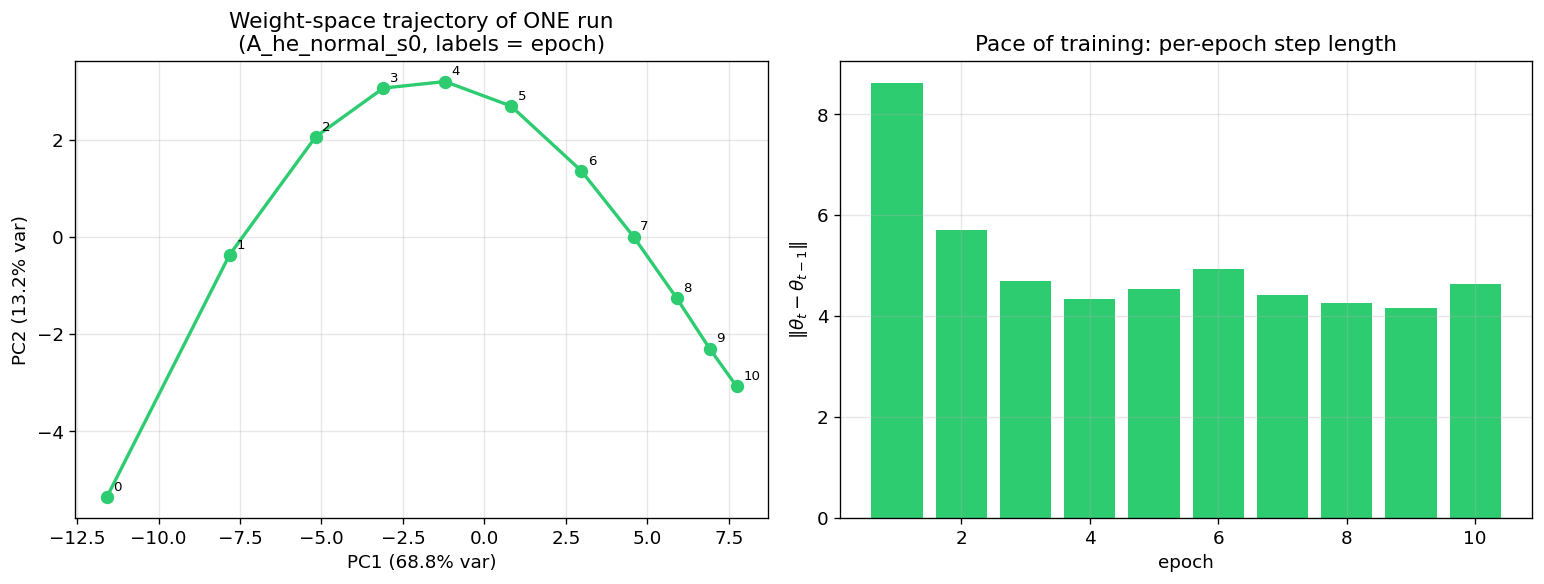

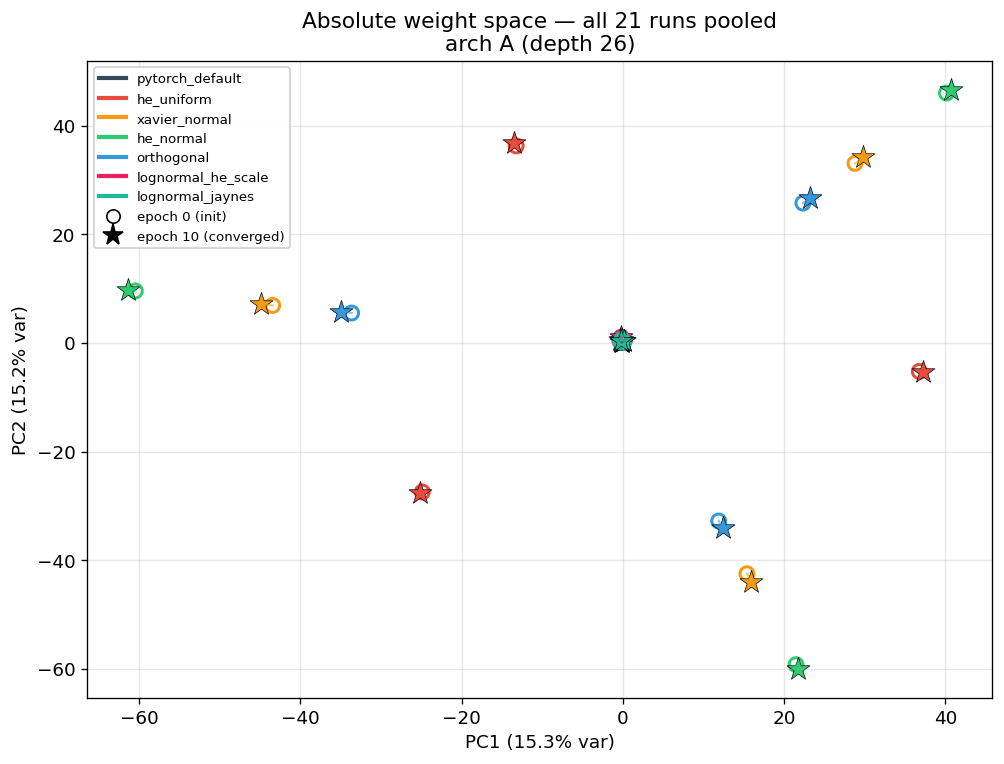

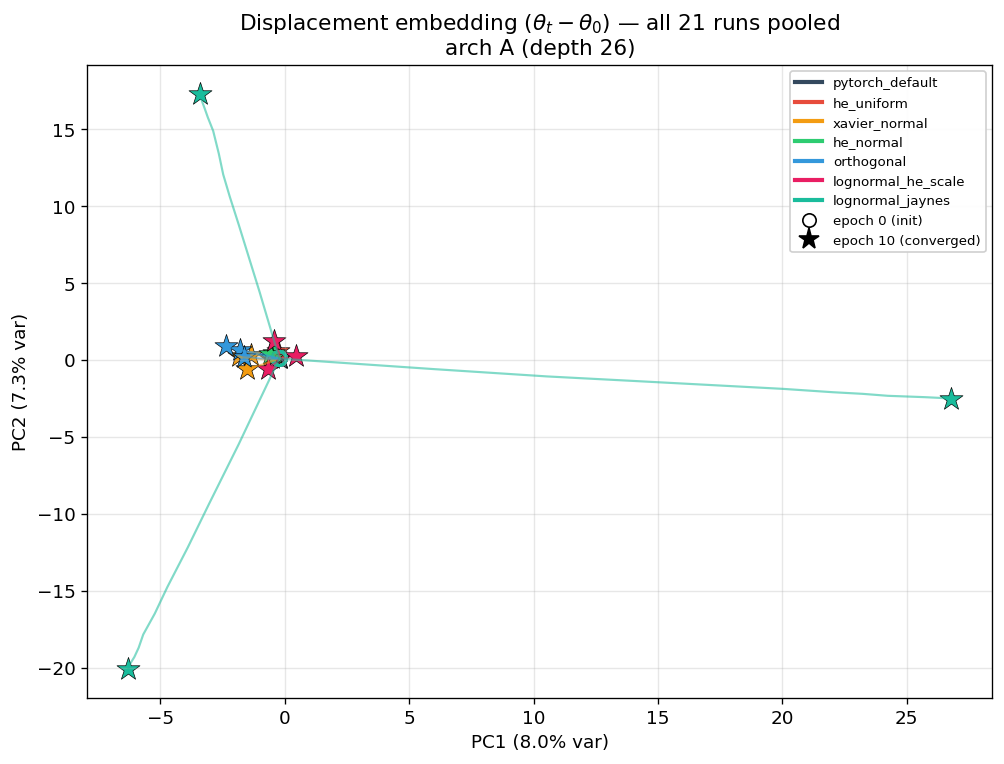

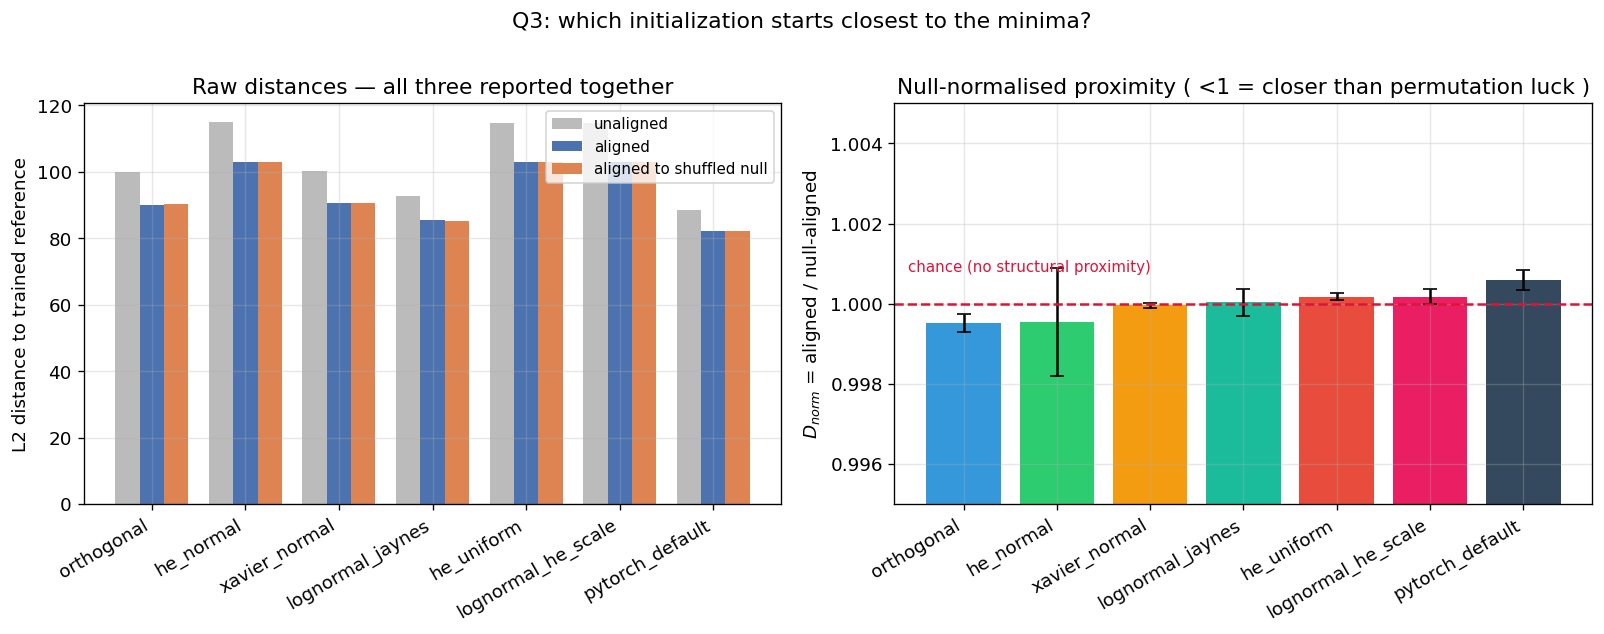

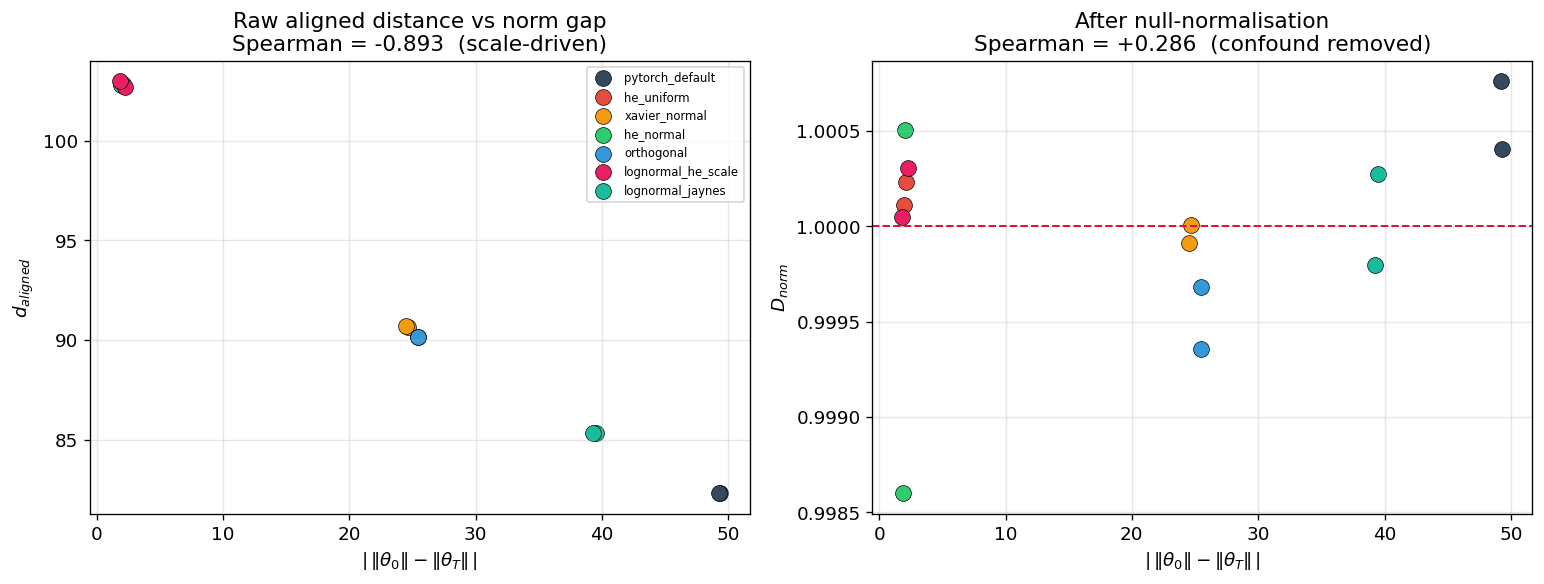

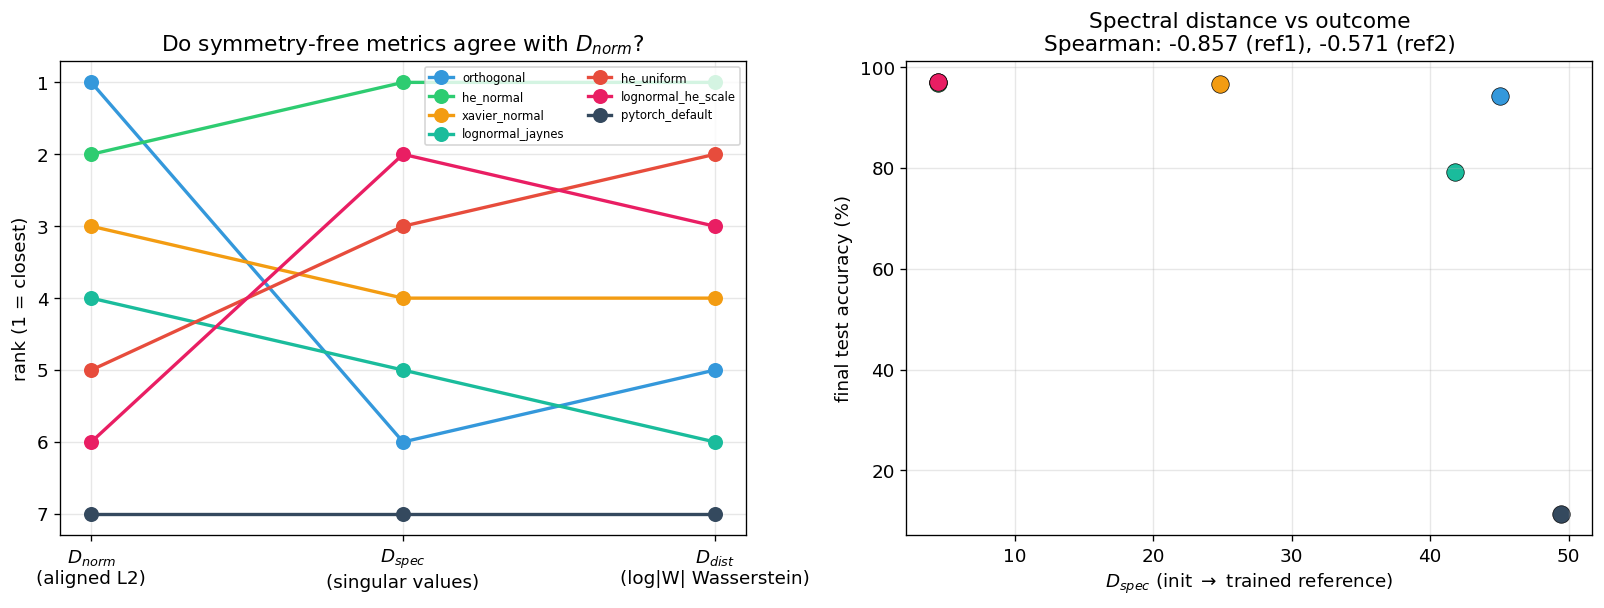

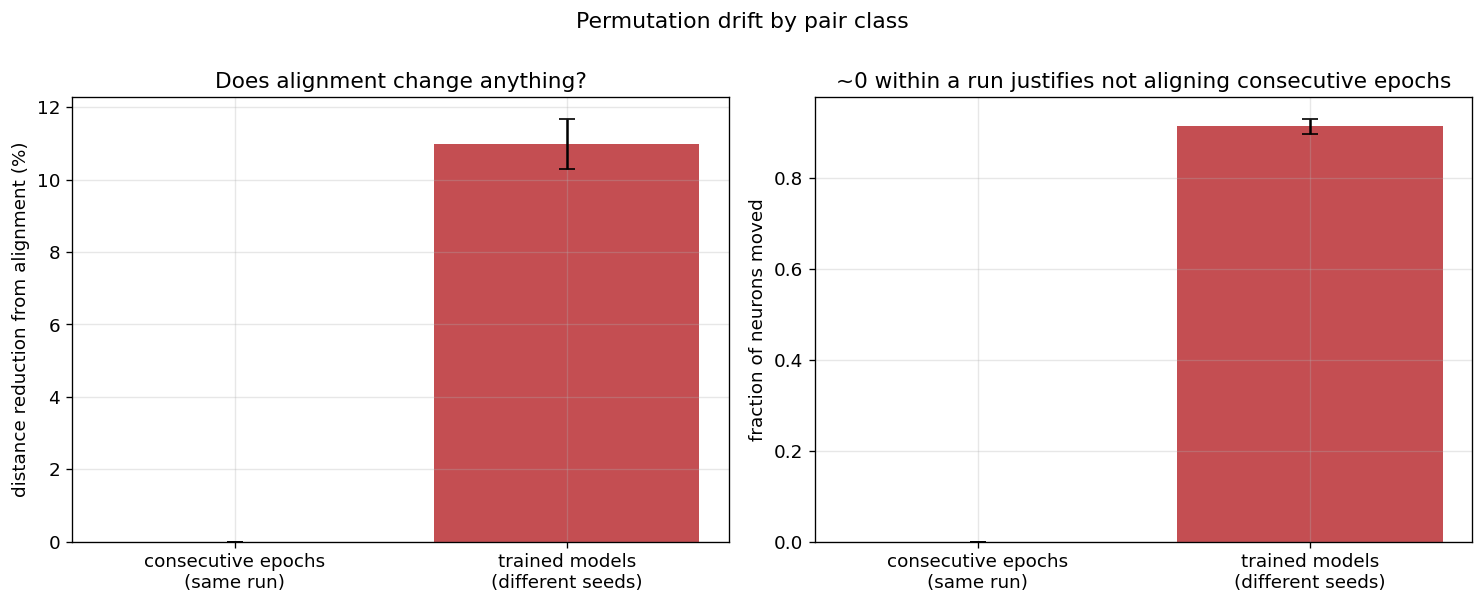

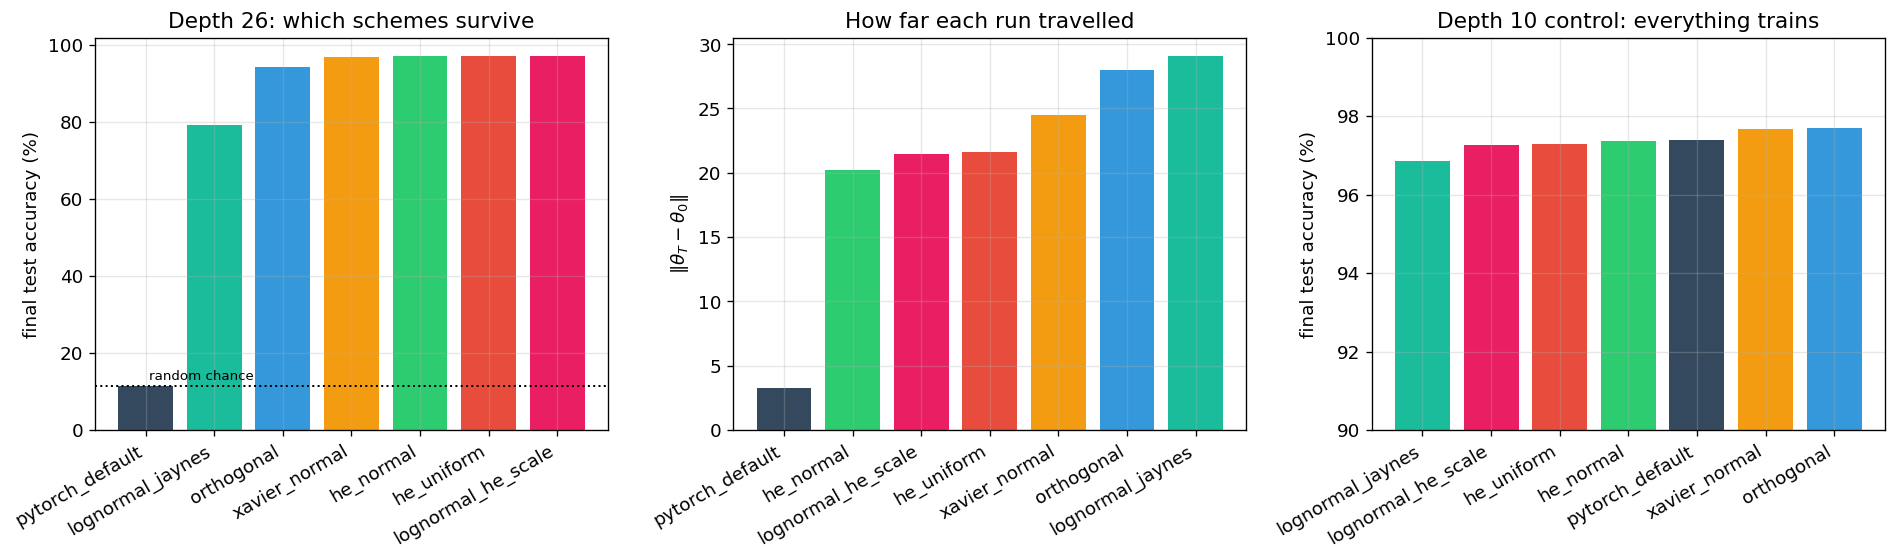

,fig_file,points_file,description,n_points
0,fig1_single_run_trajectory.png,fig1_single_run_trajectory_points.csv,Single-run weight trajectory and per-epoch ste...,11
1,fig2_pooled_absolute.png,fig2_pooled_absolute_points.csv,"Pooled absolute embedding, arch A",231
2,fig3_pooled_displacement.png,fig3_pooled_displacement_points.csv,"Pooled displacement embedding, arch A",231
3,fig4_distance_to_minima.png,fig4_distance_to_minima_points.csv,Distance from each init to the trained reference,7
4,fig5_radial_confound.png,fig5_radial_confound_points.csv,Radial (scale) confound before and after null-...,14
5,fig6_invariant_crosscheck.png,fig6_invariant_crosscheck_points.csv,Permutation-invariant metrics vs D_norm and vs...,7
6,fig7_alignment_necessity.png,fig7_alignment_necessity_points.csv,Permutation drift within a run vs across runs,2
7,fig8_sanity_checks.png,fig8_sanity_checks_points.csv,Behavioural sanity checks at depth 26 and dept...,7


In [9]:
FIGURES, manifest = {}, []

def register(name, desc, fig, pts):
    fig.savefig(OUT/f'{name}.png', dpi=150, bbox_inches='tight')
    pts.to_csv(OUT/f'{name}_points.csv', index=False)
    manifest.append(dict(fig_file=f'{name}.png', points_file=f'{name}_points.csv',
                         description=desc, n_points=len(pts)))
    FIGURES[name] = (fig, pts)

# ── Fig 1: does the embedding show a trajectory at all? (single run) ────────
Xr = np.stack([load_vec('A','he_normal',0,e).astype(np.float32) for e in range(EPOCHS+1)])
sc1, evr1 = gram_pca(Xr)
step = [0.0] + [float(np.linalg.norm(Xr[e]-Xr[e-1])) for e in range(1, EPOCHS+1)]
p1 = pd.DataFrame(dict(epoch=range(EPOCHS+1), PC1=sc1[:,0], PC2=sc1[:,1], step_size=step,
                       test_acc=hist[hist.run_id=='A_he_normal_s0'].iloc[0]['acc_curve']))
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(sc1[:,0], sc1[:,1], '-o', color='#2ecc71', lw=2, ms=7)
for e in range(EPOCHS+1):
    ax[0].annotate(str(e), (sc1[e,0], sc1[e,1]), fontsize=8, xytext=(4,4), textcoords='offset points')
ax[0].set_xlabel(f'PC1 ({evr1[0]*100:.1f}% var)'); ax[0].set_ylabel(f'PC2 ({evr1[1]*100:.1f}% var)')
ax[0].set_title('Weight-space trajectory of ONE run\n(A_he_normal_s0, labels = epoch)')
ax[1].bar(range(1, EPOCHS+1), step[1:], color='#2ecc71')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel(r'$\|\theta_t-\theta_{t-1}\|$')
ax[1].set_title('Pace of training: per-epoch step length')
fig.tight_layout()
register('fig1_single_run_trajectory',
         'Single-run weight trajectory and per-epoch step length', fig, p1)

# ── Fig 2/3: pooled embeddings ─────────────────────────────────────────────
def traj_fig(kind):
    s = snaps[snaps.arch=='A']; x, y = f'PC1_{kind}', f'PC2_{kind}'
    e = EVR['A']['absolute' if kind=='abs' else 'displacement']
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    for init in INITS:
        for seed in SEEDS:
            r = s[(s.init==init)&(s.seed==seed)].sort_values('epoch')
            ax.plot(r[x], r[y], '-', color=C(init), alpha=0.55, lw=1.3)
            ax.scatter(r[x].iloc[0], r[y].iloc[0], facecolors='none', edgecolors=C(init), s=70, lw=1.8)
            ax.scatter(r[x].iloc[-1], r[y].iloc[-1], color=C(init), marker='*', s=210,
                       edgecolors='k', linewidths=0.4)
    h = [plt.Line2D([],[],color=C(i),lw=2.5,label=i) for i in INITS]
    h += [plt.Line2D([],[],ls='none',marker='o',mfc='none',mec='k',ms=8,label='epoch 0 (init)'),
          plt.Line2D([],[],ls='none',marker='*',color='k',ms=13,label='epoch 10 (converged)')]
    ax.legend(handles=h, fontsize=8, framealpha=0.92)
    ax.set_xlabel(f'PC1 ({e[0]*100:.1f}% var)'); ax.set_ylabel(f'PC2 ({e[1]*100:.1f}% var)')
    ax.set_title(('Absolute weight space — all 21 runs pooled' if kind=='abs'
                  else 'Displacement embedding ($\\theta_t-\\theta_0$) — all 21 runs pooled')
                 + '\narch A (depth 26)')
    fig.tight_layout()
    return fig, s[['run_id','init','seed','epoch','test_acc',x,y,'norm_theta','dist_from_own_init']].copy()

f, p = traj_fig('abs');  register('fig2_pooled_absolute', 'Pooled absolute embedding, arch A', f, p)
f, p = traj_fig('disp'); register('fig3_pooled_displacement', 'Pooled displacement embedding, arch A', f, p)

# ── Fig 4: which init starts closest (D_norm) ──────────────────────────────
def rank_table(tag):
    p = pair[(pair.ref_tag==tag) & ~pair.same_run & ~pair.same_seed]
    return p.groupby('init').agg(d_unaligned=('d_unaligned','mean'), d_aligned=('d_aligned','mean'),
        d_null=('d_null_aligned','mean'), D_norm=('D_norm','mean'), D_norm_sd=('D_norm','std'),
        alignment_gain=('alignment_gain','mean'), norm_gap=('norm_gap','mean'),
        cos_aligned=('cos_aligned','mean'), D_spec=('D_spec','mean'),
        D_dist=('D_dist','mean')).reset_index().sort_values('D_norm')

g = rank_table('ref1')
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2)); xs = np.arange(len(g)); w = .26
ax[0].bar(xs-w, g.d_unaligned, w, label='unaligned', color='#bbbbbb')
ax[0].bar(xs,   g.d_aligned,   w, label='aligned',   color='#4c72b0')
ax[0].bar(xs+w, g.d_null,      w, label='aligned to shuffled null', color='#dd8452')
ax[0].set_xticks(xs); ax[0].set_xticklabels(g.init, rotation=30, ha='right')
ax[0].set_ylabel('L2 distance to trained reference'); ax[0].legend()
ax[0].set_title('Raw distances — all three reported together')
ax[1].bar(xs, g.D_norm, yerr=g.D_norm_sd.fillna(0), color=[C(i) for i in g.init], capsize=4)
ax[1].axhline(1.0, color='crimson', ls='--', lw=1.5)
ax[1].text(0.02, 1.0008, 'chance (no structural proximity)', color='crimson', fontsize=9,
           transform=ax[1].get_yaxis_transform())
ax[1].set_xticks(xs); ax[1].set_xticklabels(g.init, rotation=30, ha='right')
ax[1].set_ylabel(r'$D_{norm}$ = aligned / null-aligned')
ax[1].set_ylim(0.995, 1.005)
ax[1].set_title('Null-normalised proximity ( <1 = closer than permutation luck )')
fig.suptitle('Q3: which initialization starts closest to the minima?', y=1.01); fig.tight_layout()
register('fig4_distance_to_minima', 'Distance from each init to the trained reference', fig, g)

# ── Fig 5: the radial confound ─────────────────────────────────────────────
p5 = pair[(pair.ref_tag=='ref1') & ~pair.same_run & ~pair.same_seed]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for init in INITS:
    q = p5[p5.init==init]
    ax[0].scatter(q.norm_gap, q.d_aligned, color=C(init), s=90, label=init, edgecolors='k', lw=.4)
    ax[1].scatter(q.norm_gap, q.D_norm,    color=C(init), s=90, edgecolors='k', lw=.4)
rho_raw  = g.d_aligned.rank().corr(g.norm_gap.rank(), method='spearman')
rho_norm = g.D_norm.rank().corr(g.norm_gap.rank(), method='spearman')
ax[0].set_xlabel(r'$|\,\|\theta_0\|-\|\theta_T\|\,|$'); ax[0].set_ylabel(r'$d_{aligned}$')
ax[0].set_title(f'Raw aligned distance vs norm gap\nSpearman = {rho_raw:+.3f}  (scale-driven)')
ax[0].legend(fontsize=7)
ax[1].axhline(1.0, color='crimson', ls='--', lw=1.2)
ax[1].set_xlabel(r'$|\,\|\theta_0\|-\|\theta_T\|\,|$'); ax[1].set_ylabel(r'$D_{norm}$')
ax[1].set_title(f'After null-normalisation\nSpearman = {rho_norm:+.3f}  (confound removed)')
fig.tight_layout()
register('fig5_radial_confound', 'Radial (scale) confound before and after null-normalisation',
         fig, p5[['init','seed','norm_gap','d_aligned','D_norm','cos_aligned','norm_init','norm_ref']])

# ── Fig 6: permutation-invariant cross-check ───────────────────────────────
g1, g2 = rank_table('ref1'), rank_table('ref2')
acc = hist[hist.arch=='A'].groupby('init').final_acc.mean()
cc = g1[['init','D_norm','D_spec','D_dist']].copy()
cc['final_acc'] = cc.init.map(acc)
for m in ['D_norm','D_spec','D_dist']: cc[f'rank_{m}'] = cc[m].rank().astype(int)
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2))
for _, r in cc.iterrows():
    ax[0].plot([0,1,2], [r.rank_D_norm, r.rank_D_spec, r.rank_D_dist], '-o',
               color=C(r.init), lw=2, ms=8, label=r.init)
ax[0].set_xticks([0,1,2]); ax[0].set_xticklabels(['$D_{norm}$\n(aligned L2)','$D_{spec}$\n(singular values)','$D_{dist}$\n(log|W| Wasserstein)'])
ax[0].set_ylabel('rank (1 = closest)'); ax[0].invert_yaxis(); ax[0].legend(fontsize=7, ncol=2)
ax[0].set_title('Do symmetry-free metrics agree with $D_{norm}$?')
for init in INITS:
    ax[1].scatter(cc[cc.init==init].D_spec, cc[cc.init==init].final_acc, color=C(init), s=110,
                  edgecolors='k', lw=.4, label=init)
r_s1 = g1.set_index('init').D_spec.corr(acc, method='spearman')
r_s2 = g2.set_index('init').D_spec.corr(acc, method='spearman')
ax[1].set_xlabel(r'$D_{spec}$ (init $\rightarrow$ trained reference)'); ax[1].set_ylabel('final test accuracy (%)')
ax[1].set_title(f'Spectral distance vs outcome\nSpearman: {r_s1:+.3f} (ref1), {r_s2:+.3f} (ref2)')
fig.tight_layout()
register('fig6_invariant_crosscheck', 'Permutation-invariant metrics vs D_norm and vs outcome', fig, cc)

# ── Fig 7: when does alignment matter? ─────────────────────────────────────
gd = drift.groupby('pair_class').agg(red=('reduction_pct','mean'), red_sd=('reduction_pct','std'),
                                     moved=('frac_neurons_moved','mean'),
                                     moved_sd=('frac_neurons_moved','std'), n=('reduction_pct','size')).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(12.5, 5)); xs = np.arange(len(gd))
ax[0].bar(xs, gd.red, yerr=gd.red_sd.fillna(0), capsize=5, color=['#55a868','#c44e52'])
ax[0].set_xticks(xs); ax[0].set_xticklabels(gd.pair_class); ax[0].set_ylabel('distance reduction from alignment (%)')
ax[0].set_title('Does alignment change anything?')
ax[1].bar(xs, gd.moved, yerr=gd.moved_sd.fillna(0), capsize=5, color=['#55a868','#c44e52'])
ax[1].set_xticks(xs); ax[1].set_xticklabels(gd.pair_class); ax[1].set_ylabel('fraction of neurons moved')
ax[1].set_title('~0 within a run justifies not aligning consecutive epochs')
fig.suptitle('Permutation drift by pair class', y=1.0); fig.tight_layout()
register('fig7_alignment_necessity', 'Permutation drift within a run vs across runs', fig, gd)

# ── Fig 8: sanity against known behaviour ──────────────────────────────────
fa = snaps[(snaps.arch=='A') & (snaps.epoch==EPOCHS)]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
a1 = fa.groupby('init').test_acc.mean().sort_values()
ax[0].bar(range(len(a1)), a1.values, color=[C(i) for i in a1.index])
ax[0].axhline(11.35, color='k', ls=':', lw=1.2); ax[0].text(0.05, 13, 'random chance', fontsize=8)
ax[0].set_xticks(range(len(a1))); ax[0].set_xticklabels(a1.index, rotation=30, ha='right')
ax[0].set_ylabel('final test accuracy (%)'); ax[0].set_title('Depth 26: which schemes survive')
m1 = fa.groupby('init').dist_from_own_init.mean().sort_values()
ax[1].bar(range(len(m1)), m1.values, color=[C(i) for i in m1.index])
ax[1].set_xticks(range(len(m1))); ax[1].set_xticklabels(m1.index, rotation=30, ha='right')
ax[1].set_ylabel(r'$\|\theta_T-\theta_0\|$'); ax[1].set_title('How far each run travelled')
b1 = snaps[(snaps.arch=='B') & (snaps.epoch==EPOCHS)].groupby('init').test_acc.mean().sort_values()
ax[2].bar(range(len(b1)), b1.values, color=[C(i) for i in b1.index])
ax[2].set_xticks(range(len(b1))); ax[2].set_xticklabels(b1.index, rotation=30, ha='right')
ax[2].set_ylabel('final test accuracy (%)'); ax[2].set_ylim(90, 100)
ax[2].set_title('Depth 10 control: everything trains')
fig.tight_layout()
pts8 = fa.groupby('init').agg(acc_depth26=('test_acc','mean'), movement=('dist_from_own_init','mean'),
                              mean_absW=('mean_absW','mean'), stable_rank=('stable_rank_mean','mean'),
                              ln_r2=('ln_r2_mean','mean')).reset_index()
pts8['acc_depth10'] = pts8.init.map(b1)
register('fig8_sanity_checks', 'Behavioural sanity checks at depth 26 and depth 10', fig, pts8)

for f, _ in FIGURES.values(): pass
plt.show()
pd.DataFrame(manifest).to_csv(OUT/'MANIFEST.csv', index=False)
display(pd.DataFrame(manifest))

## 6. Controls — do the headline statistics survive a null?

Three of the numbers above look impressive but could be produced by something trivial. Each is
now given a null it must beat.

**(a) Q1.** Is $\text{Spearman}(\text{PC1},\text{epoch})=1.000$ evidence of anything? With
$n=11$ snapshots in $d\approx5\times10^5$ dimensions, a *pure random walk* may produce it
automatically. We simulate one with the observed step-size profile, and additionally use the
**dead run** (`pytorch_default`, 11.35%, never learns) as a negative control: whatever statistic
the dead network also produces cannot be evidence of learning.

**(b) Q3.** Every check so far confirms a null; none shows the instrument would *fire* if the
effect were present. We therefore construct initializations at known proximity,
$\theta_0 = \alpha\,\pi(\theta_T) + \sqrt{1-\alpha^2}\,\varepsilon$, and measure the response
curve. We also score `shuffle(`$\theta_T$`)` — a **perfect per-layer distributional match** with
zero neuron structure.

**(c) The invariant metrics.** $D_{\text{spec}}$ and $D_{\text{dist}}$ were introduced as
symmetry-free cross-checks. We test whether they are actually independent of the scale confound.

In [10]:
# ── (a) Q1 controls ────────────────────────────────────────────────────────
def traj_stats(V):
    sc, evr = gram_pca(V.astype(np.float32))
    steps = np.array([np.linalg.norm(V[e]-V[e-1]) for e in range(1, len(V))])
    path  = steps.sum()
    chord = np.linalg.norm(V[-1]-V[0])
    dirs  = np.array([(V[e]-V[e-1])/(np.linalg.norm(V[e]-V[e-1])+1e-30) for e in range(1, len(V))])
    cos   = float(np.mean([dirs[i] @ dirs[i+1] for i in range(len(dirs)-1)]))
    rho   = scipy_stats.spearmanr(sc[:,0], np.arange(len(V))).statistic
    return dict(evr1=float(evr[0]), spearman=float(abs(rho)),
                straightness=float(chord/path), step_cos=cos)

real = np.stack([load_vec('A','he_normal',0,e) for e in range(EPOCHS+1)])
dead = np.stack([load_vec('A','pytorch_default',0,e) for e in range(EPOCHS+1)])
s_real, s_dead = traj_stats(real), traj_stats(dead)

prof = np.array([np.linalg.norm(real[e]-real[e-1]) for e in range(1, EPOCHS+1)])
rng, d_sim, N_SIM = np.random.default_rng(0), 50000, 200
rw = []
for _ in range(N_SIM):
    V = [np.zeros(d_sim)]
    for st in prof:
        gstep = rng.standard_normal(d_sim); V.append(V[-1] + st*gstep/np.linalg.norm(gstep))
    rw.append(traj_stats(np.stack(V)))
rw = pd.DataFrame(rw)

q1 = pd.DataFrame([
    dict(source='real run (he_normal, 97.3%)', **s_real),
    dict(source='DEAD run (pytorch_default, 11.35%)', **s_dead),
    dict(source=f'random walk (mean of {N_SIM})', **rw.mean().to_dict()),
    dict(source=f'random walk (95th pct)', evr1=rw.evr1.quantile(.95), spearman=rw.spearman.quantile(.95),
         straightness=rw.straightness.quantile(.95), step_cos=rw.step_cos.quantile(.95))])
display(q1.round(4))
print(f'Spearman(PC1,epoch)=1.000 occurs in {100*(rw.spearman>0.999).mean():.0f}% of random walks '
      f'-> it is forced by d>>n and carries NO information.')
print(f'The dead run gives EVR1={s_dead["evr1"]:.3f}, Spearman={s_dead["spearman"]:.3f} '
      f'-> neither statistic distinguishes learning from not learning.')
print(f'What DOES separate them: straightness {s_real["straightness"]:.3f} (real) vs '
      f'{rw.straightness.mean():.3f} (walk); step cosine {s_real["step_cos"]:+.3f} vs {rw.step_cos.mean():+.3f}.')

,source,evr1,spearman,straightness,step_cos
0,"real run (he_normal, 97.3%)",0.6885,1.0,0.3998,0.0301
1,"DEAD run (pytorch_default, 11.35%)",0.6527,1.0,0.3780,-0.1463
2,random walk (mean of 200),0.5777,1.0,0.3263,-0.0001
3,random walk (95th pct),0.5800,1.0,0.3278,0.0022


Spearman(PC1,epoch)=1.000 occurs in 100% of random walks -> it is forced by d>>n and carries NO information.
The dead run gives EVR1=0.653, Spearman=1.000 -> neither statistic distinguishes learning from not learning.
What DOES separate them: straightness 0.400 (real) vs 0.326 (walk); step cosine +0.030 vs -0.000.


,alpha,D_norm,cos_aligned,frac_perm_matched
0,0.0,1.00074,0.18223,0.89469
1,0.1,0.99980,0.18408,0.89562
2,0.2,0.99870,0.18576,0.90000
3,0.3,0.98189,0.21422,0.92875
4,0.5,0.78560,0.49843,0.99031
5,0.7,0.60895,0.70007,0.99031
6,1.0,0.00000,1.00000,0.99031


D_norm reaches 0.0000 at alpha=1.0 -> the metric is NOT pinned at 1; it can fire.
But it only departs from 1 once alpha >= 0.5; below that the aligner recovers ~0 of the
true permutation, so cos_aligned sits at ~0.20 -- the same value all 7 real schemes show.

shuffle(theta_T) -- a PERFECT per-layer distributional match, zero neuron structure --
scores D_norm = 1.00019, INSIDE the observed band [0.9995, 1.0006].
=> D_norm is blind to distributional matching BY CONSTRUCTION (the null preserves every
   per-layer marginal). Q3 therefore says nothing about the log-normal hypothesis.


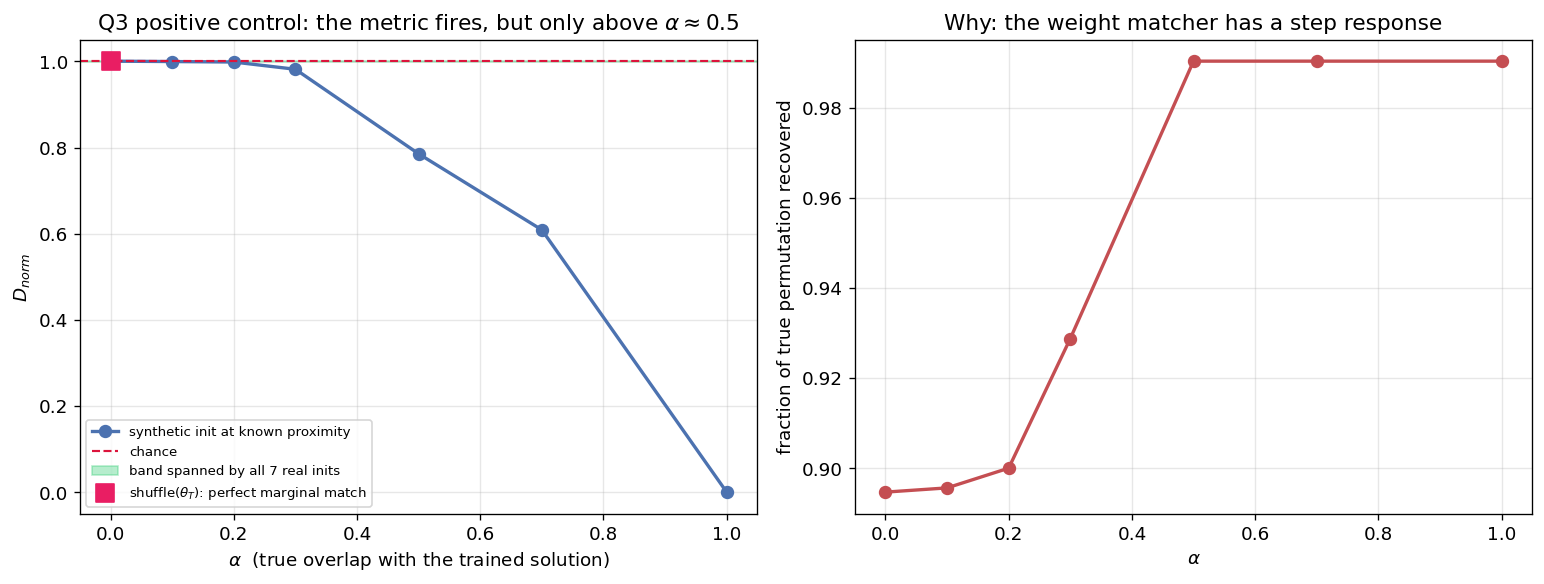

In [11]:
# ── (b) Q3 positive control: response curve at known proximity ─────────────
ref_p = to_params(load_vec('A','he_normal',0,EPOCHS), 'A')
rngc = np.random.default_rng(0)
nulls_c = [shuffle_within_layers(ref_p, rngc) for _ in range(N_NULL)]

def score(p0):
    _, _ = None, None
    pm, _ = align_params(p0, ref_p)
    da = float(np.linalg.norm(flat(p0)-flat(apply_perms(ref_p, pm))))
    dn = []
    for nl in nulls_c:
        pn, _ = align_params(p0, nl)
        dn.append(float(np.linalg.norm(flat(p0)-flat(apply_perms(nl, pn)))))
    a, b = flat(p0), flat(apply_perms(ref_p, pm))
    frac = float(np.mean([np.mean(x != np.arange(len(x))) for x in pm]))
    return da/(np.mean(dn)+1e-30), float(a@b/(np.linalg.norm(a)*np.linalg.norm(b)+1e-30)), frac

perm_true = [rngc.permutation(ref_p[l][0].shape[0]) for l in range(len(ref_p)-1)]
tgt = apply_perms(ref_p, perm_true); tn = np.linalg.norm(flat(tgt))
rows_pc = []
for alpha in [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    eps = rngc.standard_normal(len(flat(tgt))); eps *= tn/np.linalg.norm(eps)
    v = alpha*flat(tgt) + np.sqrt(1-alpha**2)*eps
    D, cs, fr = score(to_params(v, 'A'))
    rows_pc.append(dict(alpha=alpha, D_norm=D, cos_aligned=cs, frac_perm_matched=fr))
D_shuf, cos_shuf, _ = score(shuffle_within_layers(ref_p, rngc))
pc = pd.DataFrame(rows_pc)
display(pc.round(5))
real_lo, real_hi = g.D_norm.min(), g.D_norm.max()
print(f'D_norm reaches {pc.D_norm.min():.4f} at alpha=1.0 -> the metric is NOT pinned at 1; it can fire.')
print(f'But it only departs from 1 once alpha >= 0.5; below that the aligner recovers ~0 of the')
print(f'true permutation, so cos_aligned sits at ~0.20 -- the same value all 7 real schemes show.')
print()
print(f'shuffle(theta_T) -- a PERFECT per-layer distributional match, zero neuron structure --')
print(f'scores D_norm = {D_shuf:.5f}, INSIDE the observed band [{real_lo:.4f}, {real_hi:.4f}].')
print('=> D_norm is blind to distributional matching BY CONSTRUCTION (the null preserves every')
print('   per-layer marginal). Q3 therefore says nothing about the log-normal hypothesis.')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(pc.alpha, pc.D_norm, '-o', color='#4c72b0', lw=2, ms=7, label='synthetic init at known proximity')
ax[0].axhline(1.0, color='crimson', ls='--', lw=1.3, label='chance')
ax[0].axhspan(real_lo, real_hi, color='#2ecc71', alpha=.35, label='band spanned by all 7 real inits')
ax[0].scatter([0], [D_shuf], marker='s', s=110, color='#e91e63', zorder=5,
              label=r'shuffle($\theta_T$): perfect marginal match')
ax[0].set_xlabel(r'$\alpha$  (true overlap with the trained solution)')
ax[0].set_ylabel(r'$D_{norm}$'); ax[0].legend(fontsize=8)
ax[0].set_title('Q3 positive control: the metric fires, but only above $\\alpha\\approx0.5$')
ax[1].plot(pc.alpha, pc.frac_perm_matched, '-o', color='#c44e52', lw=2, ms=7)
ax[1].set_xlabel(r'$\alpha$'); ax[1].set_ylabel('fraction of true permutation recovered')
ax[1].set_title('Why: the weight matcher has a step response')
fig.tight_layout()
pc2 = pc.copy(); pc2['shuffle_control_D_norm'] = D_shuf
pc2['real_band_lo'], pc2['real_band_hi'] = real_lo, real_hi
register('fig9_q3_positive_control', 'Q3 calibration: D_norm response at known proximity', fig, pc2)

In [12]:
# ── (c) are the "invariant" metrics independent of scale? ──────────────────
inv = g[['init','D_norm','D_spec','D_dist','norm_gap','d_aligned']].copy()
inv['final_acc'] = inv.init.map(acc)
sp = lambda a, b: scipy_stats.spearmanr(a, b).statistic
t = pd.DataFrame([
    dict(metric='D_spec', rho_with_norm_gap=sp(inv.D_spec, inv.norm_gap), rho_with_acc=sp(inv.D_spec, inv.final_acc)),
    dict(metric='D_dist', rho_with_norm_gap=sp(inv.D_dist, inv.norm_gap), rho_with_acc=sp(inv.D_dist, inv.final_acc)),
    dict(metric='norm_gap (raw scale)', rho_with_norm_gap=1.0, rho_with_acc=sp(inv.norm_gap, inv.final_acc)),
    dict(metric='d_aligned (raw)', rho_with_norm_gap=sp(inv.d_aligned, inv.norm_gap), rho_with_acc=sp(inv.d_aligned, inv.final_acc))])
display(t.round(3))
print('D_spec and D_dist rank the schemes essentially the same way the plain norm gap does,')
print('and D_spec reproduces the norm gap\'s correlation with accuracy exactly. They are')
print('re-encodings of weight SCALE, not independent structural probes -- so the apparent')
print('"spectral distance predicts collapse" lead is withdrawn: it is Q2 restated.')
print()
print('Note this also corrects Sec. 2: sigma(cW)=c*sigma(W) and log|cW|=log|W|+log c, so neither')
print('companion is scale-insensitive. ReLU rescaling remains genuinely unhandled.')

,metric,rho_with_norm_gap,rho_with_acc
0,D_spec,0.929,-0.857
1,D_dist,1.000,-0.857
2,norm_gap (raw scale),1.000,-0.857
3,d_aligned (raw),-0.893,0.964


D_spec and D_dist rank the schemes essentially the same way the plain norm gap does,
and D_spec reproduces the norm gap's correlation with accuracy exactly. They are
re-encodings of weight SCALE, not independent structural probes -- so the apparent
"spectral distance predicts collapse" lead is withdrawn: it is Q2 restated.

Note this also corrects Sec. 2: sigma(cW)=c*sigma(W) and log|cW|=log|W|+log c, so neither
companion is scale-insensitive. ReLU rescaling remains genuinely unhandled.


## 7. Initializations before any training (20 seeds)

The directive asks about "dead models with no training". Using the untrained population — 20
seeds per scheme, epoch 0 only — we characterise where each scheme starts, independent of any
optimization.

,init,norm_mean,norm_sd,absW_mean,absW_sd,srank_mean,srank_sd,n,final_acc_depth26
5,pytorch_default,32.8400,0.0180,0.0432,0.0000,33.6736,0.2165,20,11.3500
3,lognormal_jaynes,42.7757,0.0694,0.0492,0.0001,32.6885,0.2365,20,79.2133
4,orthogonal,56.6569,0.0000,0.0691,0.0000,123.4614,0.0000,20,94.3100
6,xavier_normal,57.5225,0.0764,0.0702,0.0001,33.2716,0.2441,20,96.7700
0,he_normal,80.1022,0.1091,0.0974,0.0002,33.2716,0.2441,20,96.9733
2,lognormal_he_scale,80.1162,0.1288,0.0989,0.0001,32.6885,0.2365,20,97.0033
1,he_uniform,80.1253,0.0599,0.1058,0.0001,33.7214,0.2002,20,96.9933


Spearman(mean|W| at epoch 0, final accuracy at depth 26) = +0.964  (n=7 schemes)
The two schemes that fail at depth 26 are the two smallest-magnitude initializations.
Note this is close to true by construction: these schemes differ in variance by design,
so this restates the init formulas. The non-trivial version (does seed-level position
predict fate WITHIN one scheme?) needs a boundary sweep -- see Next step.


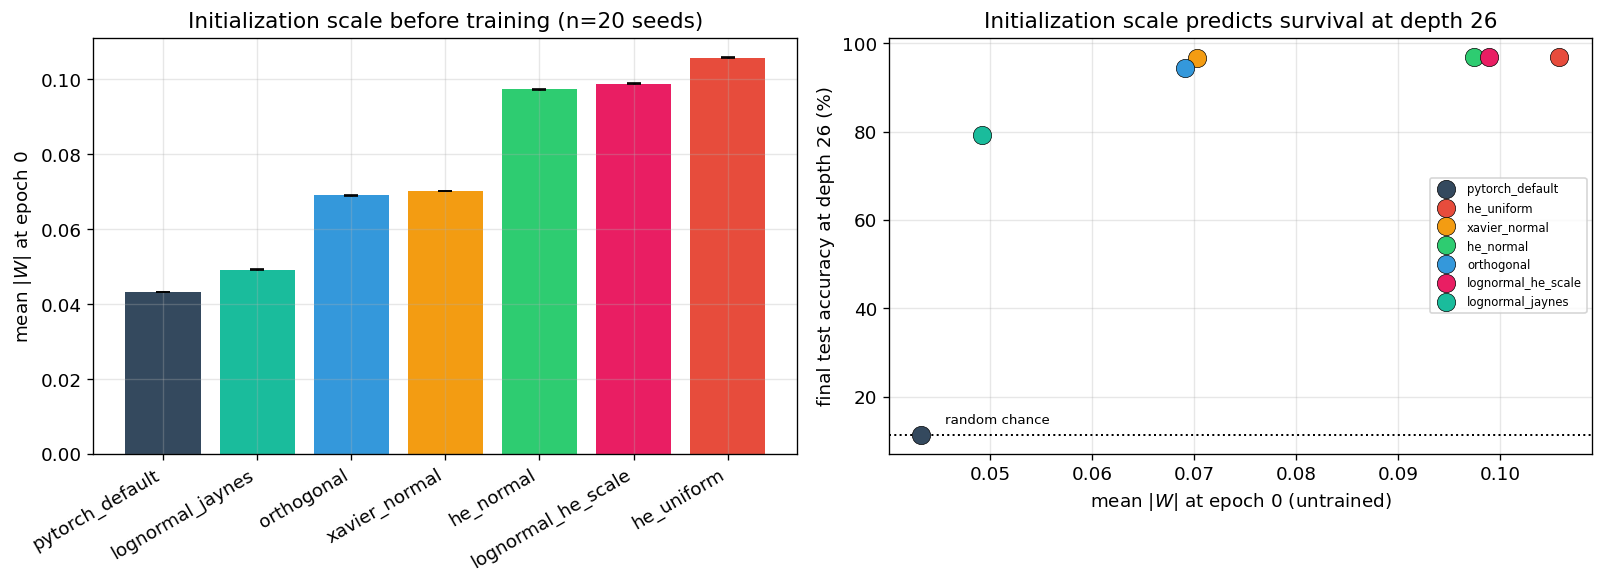

In [13]:
rows_u = []
for arch in ARCHS:
    for init in INITS:
        for s in UNTRAINED_SEEDS:
            p = SNAP_UN/f'{arch}_{init}_s{s}_ep00.npy'
            if not p.exists(): continue
            v = np.load(p).astype(np.float64)
            st = summarize(to_params(v, arch))
            rows_u.append(dict(arch=arch, init=init, seed=s, norm_theta=float(np.linalg.norm(v)), **st))
untr = pd.DataFrame(rows_u); untr.to_csv(OUT/'untrained_population.csv', index=False)

ua = untr[untr.arch=='A'].groupby('init').agg(
    norm_mean=('norm_theta','mean'), norm_sd=('norm_theta','std'),
    absW_mean=('mean_absW','mean'), absW_sd=('mean_absW','std'),
    srank_mean=('stable_rank_mean','mean'), srank_sd=('stable_rank_mean','std'),
    n=('seed','size')).reset_index()
ua['final_acc_depth26'] = ua.init.map(acc)
ua = ua.sort_values('absW_mean')
display(ua.round(4))

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5))
xs = np.arange(len(ua))
ax[0].bar(xs, ua.absW_mean, yerr=ua.absW_sd, capsize=4, color=[C(i) for i in ua.init])
ax[0].set_xticks(xs); ax[0].set_xticklabels(ua.init, rotation=30, ha='right')
ax[0].set_ylabel(r'mean $|W|$ at epoch 0'); ax[0].set_title(f'Initialization scale before training (n={ua.n.iloc[0]} seeds)')
for init in INITS:
    q = ua[ua.init==init]
    ax[1].errorbar(q.absW_mean, q.final_acc_depth26, xerr=q.absW_sd, fmt='o', ms=11,
                   color=C(init), ecolor=C(init), capsize=3, label=init, mec='k', mew=.4)
ax[1].axhline(11.35, color='k', ls=':', lw=1.2)
ax[1].text(0.0455, 14, 'random chance', fontsize=8)
ax[1].set_xlabel(r'mean $|W|$ at epoch 0 (untrained)'); ax[1].set_ylabel('final test accuracy at depth 26 (%)')
ax[1].set_title('Initialization scale predicts survival at depth 26')
ax[1].legend(fontsize=7)
fig.tight_layout()
register('fig10_untrained_population', 'Untrained population: init scale vs eventual survival', fig, ua)
print(f'Spearman(mean|W| at epoch 0, final accuracy at depth 26) = '
      f'{scipy_stats.spearmanr(ua.absW_mean, ua.final_acc_depth26).statistic:+.3f}  (n={len(ua)} schemes)')
print('The two schemes that fail at depth 26 are the two smallest-magnitude initializations.')
print('Note this is close to true by construction: these schemes differ in variance by design,')
print('so this restates the init formulas. The non-trivial version (does seed-level position')
print('predict fate WITHIN one scheme?) needs a boundary sweep -- see Next step.')

### Tables

In [14]:
print('='*100); print('T1  ACCURACY BY INITIALIZATION AND DEPTH'); print('='*100)
t1 = hist.pivot_table(index='init', columns='arch', values='final_acc', aggfunc='mean').round(2)
t1.columns = ['depth 26', 'depth 10']
t1['survives_depth26'] = t1['depth 26'] > FUNCTIONAL_ACC
display(t1.sort_values('depth 26'))

print('='*100); print('T2  Q1 — PACE OF TRAINING (single run, A_he_normal_s0)'); print('='*100)
t2 = FIGURES['fig1_single_run_trajectory'][1].copy()
t2['pct_of_total_movement'] = (100*t2.step_size/t2.step_size.sum()).round(2)
display(t2.round(3))
print(f'Spearman(PC1, epoch) = {t2.PC1.corr(t2.epoch, method="spearman"):.3f}   '
      f'PC1 explains {evr1[0]*100:.1f}% of within-run variance')
print(f'First 3 epochs carry {t2.pct_of_total_movement[1:4].sum():.1f}% of all movement; '
      f'last 3 carry {t2.pct_of_total_movement[8:].sum():.1f}%')

print('='*100); print('T3  Q3 — RANKING BY D_norm  (same_run and same_seed pairs excluded)'); print('='*100)
t3 = rank_table('ref1').set_index('init').round(4)
t3.insert(0, 'rank', range(1, len(t3)+1))
display(t3)

print('='*100); print('T3b  NOISE FLOOR BEHIND THE D_norm ERROR BARS'); print('='*100)
n_eff = pair[(pair.ref_tag=='ref1') & ~pair.same_run & ~pair.same_seed].groupby('init').size()
print(f'Pairs behind each D_norm mean: {n_eff.min()}-{n_eff.max()} per scheme '
      f'(21 total - 1 same_run - 7 same_seed = 14).')
_p0 = to_params(load_vec('A','he_normal',1,0), 'A')
_rg = np.random.default_rng(99)
_dn = []
for _ in range(8):
    _nl = shuffle_within_layers(to_params(load_vec('A','he_normal',0,EPOCHS), 'A'), _rg)
    _pm, _ = align_params(_p0, _nl)
    _dn.append(float(np.linalg.norm(flat(_p0)-flat(apply_perms(_nl, _pm)))))
_floor = float(np.std(_dn)/np.mean(_dn))
print(f'Null-draw relative sd (8 draws): {_floor:.2e}')
print(f'Total spread between all 7 schemes: {(t3.D_norm.max()-t3.D_norm.min()):.2e}')
print('-> the between-scheme spread is the same order as the measurement noise. The correct')
print('   reading is that all schemes are indistinguishable, NOT that their ordering is real.')

print('='*100); print('T4  ROBUSTNESS ACROSS THE TWO REFERENCE MODELS'); print('='*100)
r1 = g1.set_index('init').D_norm.rank(); r2 = g2.set_index('init').D_norm.rank()
t4 = pd.DataFrame({'rank_ref1': r1.astype(int), 'rank_ref2': r2.astype(int)})
t4['agree'] = t4.rank_ref1 == t4.rank_ref2
display(t4.sort_values('rank_ref1'))
rho = r1.corr(r2, method='spearman')
print(f'Spearman between references (D_norm): {rho:+.3f}  -> '
      + ('STABLE' if rho > 0.8 else 'ranking is NOT stable; treat as inconclusive'))
for m in ['D_spec','D_dist']:
    c1 = g1.set_index('init')[m].corr(acc, method='spearman')
    c2 = g2.set_index('init')[m].corr(acc, method='spearman')
    ag = g1.set_index('init')[m].rank().corr(g2.set_index('init')[m].rank(), method='spearman')
    print(f'  {m}: Spearman(metric, accuracy) = {c1:+.3f} (ref1) / {c2:+.3f} (ref2); '
          f'ranking agreement {ag:+.3f}')

print('='*100); print('T5  MINIMA CLOUD — how far apart are converged solutions?'); print('='*100)
cl = cloud[~cloud.same_seed]          # same-seed pairs share the RNG draw (see Sec. 5)
display(pd.DataFrame([dict(n_pairs=len(cl), mean_aligned=round(cl.d_aligned.mean(),2),
                           sd=round(cl.d_aligned.std(),2), min=round(cl.d_aligned.min(),2),
                           max=round(cl.d_aligned.max(),2),
                           contaminated_pairs_dropped=int(cloud.same_seed.sum()))]))
print(f'Converged solutions sit {cl.d_aligned.mean():.1f} +/- {cl.d_aligned.std():.1f} apart after alignment')
print(f'(range {cl.d_aligned.min():.1f}-{cl.d_aligned.max():.1f}). The "minima" are a broad cloud, not a point,')
print('so a single mean is not a meaningful "width" and no init-vs-cloud comparison is made here.')
print('NOTE: comparing an init to this cloud by RAW d_aligned would crown pytorch_default (the dead')
print('scheme) -- that metric is discredited in Sec. 5/6c and is deliberately not used.')

print('='*100); print('T6  ALIGNMENT NECESSITY BY PAIR CLASS'); print('='*100)
display(drift.groupby('pair_class').agg(n=('reduction_pct','size'),
        mean_reduction_pct=('reduction_pct','mean'),
        mean_frac_neurons_moved=('frac_neurons_moved','mean')).round(4))

T1  ACCURACY BY INITIALIZATION AND DEPTH


,depth 26,depth 10,survives_depth26
init,,,
pytorch_default,11.35,97.39,False
lognormal_jaynes,79.21,96.85,True
orthogonal,94.31,97.69,True
xavier_normal,96.77,97.68,True
he_normal,96.97,97.38,True
he_uniform,96.99,97.29,True
lognormal_he_scale,97.00,97.27,True


T2  Q1 — PACE OF TRAINING (single run, A_he_normal_s0)


,epoch,PC1,PC2,step_size,test_acc,pct_of_total_movement
0,0,-11.582,-5.350,0.000,10.31,0.00
1,1,-7.820,-0.371,8.627,93.92,17.16
2,2,-5.182,2.055,5.699,95.19,11.34
3,3,-3.102,3.059,4.694,95.94,9.34
4,4,-1.210,3.193,4.332,96.14,8.62
5,5,0.814,2.690,4.526,96.30,9.01
6,6,2.970,1.357,4.922,96.22,9.79
7,7,4.573,0.003,4.417,97.00,8.79
8,8,5.897,-1.262,4.263,97.19,8.48
9,9,6.909,-2.300,4.154,97.30,8.27


Spearman(PC1, epoch) = 1.000   PC1 explains 68.8% of within-run variance
First 3 epochs carry 37.8% of all movement; last 3 carry 25.9%
T3  Q3 — RANKING BY D_norm  (same_run and same_seed pairs excluded)


...

,rank_ref1,rank_ref2,agree
init,,,
orthogonal,1,5,False
he_normal,2,1,False
xavier_normal,3,6,False
lognormal_jaynes,4,2,False
he_uniform,5,7,False
lognormal_he_scale,6,4,False
pytorch_default,7,3,False


Spearman between references (D_norm): +0.036  -> ranking is NOT stable; treat as inconclusive
  D_spec: Spearman(metric, accuracy) = -0.857 (ref1) / -0.571 (ref2); ranking agreement +0.750
  D_dist: Spearman(metric, accuracy) = -0.857 (ref1) / +0.286 (ref2); ranking agreement +0.000
T5  MINIMA CLOUD — how far apart are converged solutions?


,n_pairs,mean_aligned,sd,min,max,contaminated_pairs_dropped
0,108,90.3,10.91,63.3,104.29,45


Converged solutions sit 90.3 +/- 10.9 apart after alignment
(range 63.3-104.3). The "minima" are a broad cloud, not a point,
so a single mean is not a meaningful "width" and no init-vs-cloud comparison is made here.
NOTE: comparing an init to this cloud by RAW d_aligned would crown pytorch_default (the dead
scheme) -- that metric is discredited in Sec. 5/6c and is deliberately not used.
T6  ALIGNMENT NECESSITY BY PAIR CLASS


,n,mean_reduction_pct,mean_frac_neurons_moved
pair_class,,,
consecutive epochs\n(same run),60,0.0000,0.0000
trained models\n(different seeds),21,10.9943,0.9143


### Validation checks

Hard assertions. A failure means the setup drifted out of the regime and nothing above should be
trusted.

In [15]:
checks = []
def chk(name, ok, detail): checks.append(dict(check=name, status='PASS' if ok else 'FAIL', detail=detail))

A = hist[hist.arch=='A'].groupby('init').final_acc.mean()
B = hist[hist.arch=='B'].groupby('init').final_acc.mean()
chk('V1 pytorch_default collapses at depth 26', A['pytorch_default'] < 20, f"{A['pytorch_default']:.2f}%")
chk('V2 he/xavier survive at depth 26', min(A['he_normal'], A['xavier_normal']) > 90,
    f"he {A['he_normal']:.2f}%, xavier {A['xavier_normal']:.2f}%")
chk('V3 depth-10 control: all schemes train', (B > 90).all(), f'min {B.min():.2f}%')
fa = snaps[(snaps.arch=='A') & (snaps.epoch==EPOCHS)]
dead, live = fa[fa.test_acc<20].dist_from_own_init.mean(), fa[fa.test_acc>90].dist_from_own_init.mean()
chk('V4 healthy runs travel >=3x further than dead', live/dead >= 3, f'{live:.1f} vs {dead:.1f} ({live/dead:.1f}x)')
ep0 = snaps[(snaps.arch=='A') & (snaps.epoch==0)].set_index('run_id').mean_absW
chg = (fa.set_index('run_id').mean_absW[fa[fa.test_acc<20].run_id] / ep0[fa[fa.test_acc<20].run_id]).mean()
chk('V5 dead runs are frozen at init (wd=0)', 0.95 < chg < 1.05, f'mean|W| changed {chg:.3f}x')
viol = int((pair.d_aligned < pair.D_spec - 1e-6).sum())
chk('V6 Mirsky bound: d_aligned >= D_spec', viol == 0, f'{viol} violations of {len(pair)} pairs')
cons = drift[drift.pair_class.str.startswith('consecutive')]
chk('V7 no permutation drift within a run', cons.frac_neurons_moved.mean() < 0.05,
    f'{cons.frac_neurons_moved.mean():.4f} moved, {cons.reduction_pct.mean():.2f}% reduction')
cross = drift[drift.pair_class.str.startswith('trained')]
chk('V8 alignment does matter across runs', cross.reduction_pct.mean() > 2,
    f'{cross.reduction_pct.mean():.2f}% reduction, {cross.frac_neurons_moved.mean():.3f} moved')

cdf = pd.DataFrame(checks); display(cdf)
cdf.to_csv(OUT/'validation_checks.csv', index=False)
print(f"{(cdf.status=='PASS').sum()}/{len(cdf)} checks passed")

,check,status,detail
0,V1 pytorch_default collapses at depth 26,PASS,11.35%
1,V2 he/xavier survive at depth 26,PASS,"he 96.97%, xavier 96.77%"
2,V3 depth-10 control: all schemes train,PASS,min 96.85%
3,V4 healthy runs travel >=3x further than dead,PASS,23.2 vs 3.3 (7.1x)
4,V5 dead runs are frozen at init (wd=0),PASS,mean|W| changed 0.999x
5,V6 Mirsky bound: d_aligned >= D_spec,PASS,0 violations of 42 pairs
6,V7 no permutation drift within a run,PASS,"0.0000 moved, 0.00% reduction"
7,V8 alignment does matter across runs,PASS,"10.99% reduction, 0.914 moved"


8/8 checks passed


## Appendix A — why `weight_decay = 0`

Justifying the one setting that makes this week's numbers differ from earlier weeks. Same dead
network, same seed, only weight decay changes.

In [16]:
def wd_probe(init, wd, depth=26, width=128, epochs=EPOCHS, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    m = apply_init(DynamicMLP(depth=depth, width=width), init)
    s0 = summarize(unflatten_params(flatten_params(m), depth, width))
    opt = optim.Adam(m.parameters(), lr=LR, weight_decay=wd); crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        m.train()
        for x, y in train_loader:
            opt.zero_grad(); crit(m(x), y).backward(); opt.step()
    s1 = summarize(unflatten_params(flatten_params(m), depth, width))
    return dict(init=init, weight_decay=wd, test_acc=test_accuracy(m, test_loader),
                mean_absW_ep0=s0['mean_absW'], mean_absW_ep10=s1['mean_absW'],
                magnitude_change=s1['mean_absW']/s0['mean_absW'],
                stable_rank=s1['stable_rank_mean'], ln_r2=s1['ln_r2_mean'])

wdp = pd.DataFrame([wd_probe('pytorch_default', 0.0), wd_probe('pytorch_default', 1e-4)])
wdp.to_csv(OUT/'appendixA_wd_probe.csv', index=False)
display(wdp.round(6))
print('Both rows are the same dead network at the same accuracy. With wd=0 its weights stay')
print('where they were initialised; with wd=1e-4 they are shrunk ~90x toward zero, because a')
print('dead network receives essentially no gradient and decay acts unopposed. Since this week')
print('measures DISTANCE between parameter vectors, that pull would bias every number, so wd=0.')

,init,weight_decay,test_acc,mean_absW_ep0,mean_absW_ep10,magnitude_change,stable_rank,ln_r2
0,pytorch_default,0.0000,11.35,0.043236,0.043160,0.998235,32.275853,0.818045
1,pytorch_default,0.0001,11.35,0.043236,0.000487,0.011256,0.290823,0.913837


Both rows are the same dead network at the same accuracy. With wd=0 its weights stay
where they were initialised; with wd=1e-4 they are shrunk ~90x toward zero, because a
dead network receives essentially no gradient and decay acts unopposed. Since this week
measures DISTANCE between parameter vectors, that pull would bias every number, so wd=0.


---
## Summary

**Q1 — Trajectory and pace: yes, but the obvious statistics are worthless.**
The tempting headline — PC1 explains 68.8% of within-run variance with
$\text{Spearman}(\text{PC1},\text{epoch})=1.000$ — does not survive its null. A **pure random
walk** with the same step-size profile produces $\text{EVR}_1 = 0.58$ and Spearman $=1.000$ in
**100% of 200 simulations**: with $n=11$ points in $d\approx5\times10^5$ dimensions that rank
correlation is forced, not earned. Worse, the **dead run** (`pytorch_default`, 11.35%, never
learns) gives $\text{EVR}_1 = 0.65$ and Spearman $= 1.000$ too. Neither statistic distinguishes
learning from not learning (§6a).

What *does* survive is narrower than it first appears. Straightness
($\|\theta_{10}-\theta_0\|/\text{path}$) is $0.400$ for the real run against $0.326$ for a random
walk — but the **dead** run scores $0.378$, so straightness barely separates learning from
collapse either. The one statistic that cleanly does is the **consecutive-step cosine**: $+0.030$
for the real run, $-0.000$ for a random walk, and $-0.146$ for the dead run. Healthy training has
weak but positive directional persistence; the dead network *anti*-aligns, oscillating rather
than advancing. That sign difference, not the variance explained, is the real signal — and it is
small.

The **step-size profile** is the honest deliverable for "pace" (Fig. 1, T2), and it is
interesting: epoch 1 moves $8.63$, epoch 2 moves $5.70$, and every later epoch sits on a plateau
of $4.2$–$4.9$. Against accuracy, that first epoch carries 17.2% of the total distance and takes
the network from 10.3% to **93.9%**; the remaining nine epochs cover 83% of the distance for a
further 3.4 points. **The network keeps moving at a near-constant rate long after the functional
gains stop.** One caveat: with a constant learning rate and no scheduler, Adam's per-step
displacement is only weakly tied to gradient magnitude, so a plateau is partly expected — the
observed plateau ($4.49$) is $0.42\times$ the free-running Adam bound
$\text{lr}\sqrt{d}\sqrt{\text{steps}} = 10.82$, so the step length is substantially but not
entirely optimizer-determined.

**Q2 — Initializations as starting points: separable, but partly by construction.**
At depth 26 the schemes split cleanly into survivors (`he_normal`, `he_uniform`,
`lognormal_he_scale`, `xavier_normal`, `orthogonal`, all ≈94–97%) and failures
(`pytorch_default` at 11.35%, `lognormal_jaynes` degraded to ≈79%), while at depth 10 every
scheme trains. So collapse here is a *depth × initialization-scale* interaction, not a property
of the initialization alone (Fig. 8, T1).

The honest caveat: these schemes differ in weight variance **by construction**, so separating
them at epoch 0 largely restates their definitions. The defensible claim is the weaker one —
*collapse is determined by the initialization's scale/distribution* — and it is supported by the
depth-10 control.

**Q3 — Optimal init near the minima: a bound, not an equality.**
$D_{\text{norm}} \in [0.9995, 1.0006]$ for all seven schemes — a band the same order as the
measurement's own noise floor, so the schemes are **indistinguishable** and their ordering should
not be read (T3, T3b). The between-reference rank correlation is $+0.036$: there is no
reproducible ranking at all (T4).

The metric is not vacuous — a positive control confirms it fires, reaching $D_{\text{norm}}=0$
for a permuted copy of the trained network. But it departs from 1 only once the true overlap
exceeds $\alpha\approx0.5$, because below that the weight matcher recovers essentially none of
the true permutation (Fig. 9). So the defensible statement is a **bound**: no initialization
reaches post-alignment cosine $\gtrsim0.3$ with a trained solution — which no data-independent
initialization plausibly could.

**Two caveats that limit what this says.** First, the null preserves every per-layer weight
marginal by construction, so $D_{\text{norm}}$ is **blind to distributional matching**:
`shuffle(theta_T)` — a perfect marginal match to the trained network carrying zero neuron
structure — scores $1.00019$, *inside* the band spanned by the real schemes. **This result
therefore does not test the log-normal hypothesis**; that needs a different null. Second, the
control was still load-bearing: ranked by **raw aligned distance** the apparent winner is
`pytorch_default`, *the dead scheme*, purely because its weights are smallest (Spearman $-0.893$
with the norm gap). Reporting raw distance would have produced a confident, entirely spurious
headline (Fig. 5).

**A methodological result worth carrying forward.**
Alignment across independently-seeded runs moves 91% of neurons and cuts distance by 11%; within
a single run it moves **0.0%** and changes distance by **0.00%** (Fig. 7, T6). SGD does not
permute neurons mid-training. So within-run trajectories may be read directly, but *any*
cross-run weight comparison is meaningless without alignment — which retroactively justifies
treating the two cases differently, and is worth remembering for any future weight-space work.

**A lead that was withdrawn.** Spectral distance $D_{\text{spec}}$ from an initialization to a
trained network appeared to track final accuracy (Spearman $-0.857$). It does not survive
scrutiny: $D_{\text{spec}}$ is rank-correlated $+0.929$ with the plain norm gap and reproduces the
norm gap's correlation with accuracy *exactly*, while $D_{\text{dist}}$ is rank-**identical** to it
($+1.000$). Both are re-encodings of weight scale rather than independent structural probes, so
the "lead" is simply Q2 restated (§6c). This also corrects a claim made in §2: since
$\sigma(cW)=c\,\sigma(W)$ and $\log|cW| = \log|W| + \log c$, neither companion is scale-insensitive,
and ReLU rescaling remains genuinely unhandled.

### Limitation to state plainly

Pooled across independently-seeded runs the absolute embedding is **near-isotropic**: the
explained-variance spectrum is flat (0.153 / 0.152 / 0.139) — no direction dominates. Signed PC1
correlates with nothing (ρ ≈ −0.001 with weight norm), though this is partly because a PC's sign
is arbitrary: |PC1| does track scale (ρ = +0.52 with $\|\theta\|$), so the pooled top component
encodes weight magnitude symmetrically about zero rather than encoding nothing. Two
different-seed initializations have cosine ≈ −0.002; in ~500,000 dimensions independent random
vectors are essentially orthogonal, so no 2-D projection of the pooled cloud can be faithful
(Fig. 2 vs Fig. 3). **Weight-space PCA is a within-run instrument, or a displacement-space
instrument — not a pooled one.**

### Next step

The non-trivial version of Q2 — does seed-level position at epoch 0 predict survival *within a
single scheme*? — needs a configuration sitting exactly on the collapse boundary, swept over many
seeds. That is the natural follow-up, and it is the version of the question that cannot be
answered just by restating the initialization formula.